In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path
from scipy.signal import savgol_filter
from pathlib import Path
import gwsurrogate as gws
import seaborn as sns
from scipy.optimize import curve_fit, OptimizeWarning
from tqdm.auto import tqdm
import warnings
from datetime import datetime

np.set_printoptions(
    precision=8,
    suppress=True,
    linewidth=120
)

plt.rcParams.update({
    "figure.figsize": (7.5, 5.0),
    "font.size": 12,
    "axes.grid": True,
    "lines.linewidth": 2.0,
})

G = 1.0
c = 1.0
M_TOTAL = 1.0


def kerr_entropy(M, J, return_chi=False):

    M = np.asarray(M, dtype=float)
    J = np.asarray(J, dtype=float)

    with np.errstate(divide="ignore", invalid="ignore"):
        chi = J / M**2
        radicand = 1.0 - chi**2

        S = 2.0 * np.pi * M**2 * (1.0 + np.sqrt(radicand))

    physical_mask = (
        np.isfinite(M)
        & np.isfinite(J)
        & np.isfinite(chi)
        & (M > 0.0)
        & (radicand >= 0.0)
    )

    S = np.where(physical_mask, S, np.nan)

    if return_chi:
        return S, chi

    return S

/home/giacomo/Thesis/Entropy-conjecture/.venv/lib/python3.12/site-packages/gwtools/const.py:52: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


lal.MSUN_SI != Msun


In [2]:
sur_wave_aligned = gws.LoadSurrogate('NRSur7dq4')

Loaded NRSur7dq4 model


In [3]:
def aligned_binary_parameters(q_input, chi1_z, chi2_z):
    
    q_input = float(q_input)
    chi1_z = float(chi1_z)
    chi2_z = float(chi2_z)

    if q_input <= 0:
        raise ValueError("The mass ratio must be positive.")


    if q_input <= 1.0:
        q = q_input
        chi1 = chi1_z
        chi2 = chi2_z
    else:
        q = 1.0 / q_input
        chi1 = chi2_z
        chi2 = chi1_z

    m1 = q / (1.0 + q)
    m2 = 1.0 / (1.0 + q)

    m = m1 + m2
    mu = m1 * m2 / m
    eta = mu / m

    S1_z = chi1 * m1**2
    S2_z = chi2 * m2**2
    S_z = S1_z + S2_z

    params = {
        "q": q,
        "m1": m1,
        "m2": m2,
        "m": m,
        "mu": mu,
        "eta": eta,
        "chi1_z": chi1,
        "chi2_z": chi2,
        "S1_z": S1_z,
        "S2_z": S2_z,
        "S_z": S_z,
    }

    return params

In [4]:
def aligned_entropy_curve_0PN(a_array, params):
   
    a = np.asarray(a_array, dtype=float)

    if np.any(a <= 0):
        raise ValueError("All separations must satisfy a > 0.")

    eta = params["eta"]
    S_z = params["S_z"]

    gamma = 1.0 / a

    E_bind = -0.5 * eta * gamma

    M_tot = 1.0 + E_bind

    L_orb = eta / np.sqrt(gamma)

    J_tot_z = L_orb + S_z
    J_tot_abs = np.abs(J_tot_z)

    S_Kerr, chi_Kerr = kerr_entropy(M_tot, J_tot_abs, return_chi=True)

    curve = pd.DataFrame({
        "a": a,
        "gamma": gamma,
        "E_bind_0PN": E_bind,
        "M_tot_0PN": M_tot,
        "L_orb_0PN": L_orb,
        "J_tot_z_0PN": J_tot_z,
        "J_tot_abs_0PN": J_tot_abs,
        "chi_Kerr_0PN": chi_Kerr,
        "S_Kerr_0PN": S_Kerr,
    })

    return curve

In [5]:
def aligned_entropy_curve_1PN(a_array, params):
    
    a = np.asarray(a_array, dtype=float)

    if np.any(a <= 0):
        raise ValueError("All separations must satisfy a > 0.")

    m = params["m"]
    mu = params["mu"]
    nu = params["eta"]
    S_z = params["S_z"]

    X = 1.0 / a

    E_bind_N = -0.5 * mu * X
    E_bind_1PN_corr = mu * X**2 * (7.0 - nu) / 8.0

    E_bind_1PN = E_bind_N + E_bind_1PN_corr

    M_tot_1PN = m + E_bind_1PN


    L_orb_N = mu / np.sqrt(X)
    L_orb_1PN_corr = 2.0 * mu * np.sqrt(X)

    L_orb_1PN = L_orb_N + L_orb_1PN_corr


    J_tot_z_1PN = L_orb_1PN + S_z
    J_tot_abs_1PN = np.abs(J_tot_z_1PN)

    
    S_Kerr_1PN, chi_Kerr_1PN = kerr_entropy(
        M_tot_1PN,
        J_tot_abs_1PN,
        return_chi=True
    )

    curve = pd.DataFrame({
        "a": a,
        "X": X,

        "E_bind_N": E_bind_N,
        "E_bind_1PN_corr": E_bind_1PN_corr,
        "E_bind_1PN": E_bind_1PN,

        "M_tot_1PN": M_tot_1PN,

        "L_orb_N": L_orb_N,
        "L_orb_1PN_corr": L_orb_1PN_corr,
        "L_orb_1PN": L_orb_1PN,

        "J_tot_z_1PN": J_tot_z_1PN,
        "J_tot_abs_1PN": J_tot_abs_1PN,

        "chi_Kerr_1PN": chi_Kerr_1PN,
        "S_Kerr_1PN": S_Kerr_1PN,
    })

    return curve

In [6]:
def aligned_entropy_curve_2PN(a_array, params, G=1.0, c=1.0):
    
    a = np.asarray(a_array, dtype=float)

    if np.any(a <= 0):
        raise ValueError("All separations must satisfy a > 0.")

    m1 = params["m1"]
    m2 = params["m2"]
    m = params["m"]
    mu = params["mu"]
    nu = params["eta"]

    S1L = params["S1_z"]
    S2L = params["S2_z"]

    Gamma = G / a

    B_SO = (
        S1L * (4.0 * m1 * m2 + 3.0 * m2**2)
        +
        S2L * (3.0 * m1**2 + 4.0 * m1 * m2)
    )

    B_SS = (
        2.0 * S1L * S2L
        +
        (m2 / m1) * S1L**2
        +
        (m1 / m2) * S2L**2
    )


    E_bind_N = -0.5 * mu * Gamma

    E_bind_1PN_corr = (
        mu * Gamma**2 * (7.0 - nu)
        / (8.0 * c**2)
    )

    E_bind_SO_15PN_corr = (
        - mu * Gamma**(5.0 / 2.0) * B_SO
        / (3.0 * G * c**3 * m**2 * m1 * m2)
    )

    E_bind_2PN_NS_corr = (
        mu * Gamma**3 * (7.0 - 49.0 * nu - nu**2)
        / (16.0 * c**4)
    )

    E_bind_SS_2PN_corr = (
        - Gamma**3 * B_SS
        / (2.0 * G**2 * c**4 * m**3)
    )

    E_bind_2PN = (
        E_bind_N
        + E_bind_1PN_corr
        + E_bind_SO_15PN_corr
        + E_bind_2PN_NS_corr
        + E_bind_SS_2PN_corr
    )

    M_tot_2PN = m + E_bind_2PN / c**2

    L_orb_N = G * mu * m / np.sqrt(Gamma)

    L_orb_1PN_corr = (
        2.0 * G * mu * m * np.sqrt(Gamma)
        / c**2
    )

    L_SO_15PN_corr = (
        - (5.0 / 6.0) * Gamma * B_SO
        / (c**3 * m**2)
    )

    L_orb_2PN_NS_corr = (
        G * mu * m * Gamma**(3.0 / 2.0) * (5.0 - 9.0 * nu)
        / (2.0 * c**4)
    )

    L_SS_2PN_corr = (
        - Gamma**(3.0 / 2.0) * B_SS
        / (G * c**4 * m**2)
    )

    L_ell_2PN = (
        L_orb_N
        + L_orb_1PN_corr
        + L_SO_15PN_corr
        + L_orb_2PN_NS_corr
        + L_SS_2PN_corr
    )

    J_tot_z_2PN = L_ell_2PN + (S1L + S2L) / c
    J_tot_abs_2PN = np.abs(J_tot_z_2PN)

    S_Kerr_2PN, chi_Kerr_2PN = kerr_entropy(
        M_tot_2PN,
        J_tot_abs_2PN,
        return_chi=True
    )

    curve = pd.DataFrame({
        "a": a,
        "Gamma": Gamma,

        "B_SO": B_SO,
        "B_SS": B_SS,

        "E_bind_N": E_bind_N,
        "E_bind_1PN_corr": E_bind_1PN_corr,
        "E_bind_SO_15PN_corr": E_bind_SO_15PN_corr,
        "E_bind_2PN_NS_corr": E_bind_2PN_NS_corr,
        "E_bind_SS_2PN_corr": E_bind_SS_2PN_corr,
        "E_bind_2PN": E_bind_2PN,

        "M_tot_2PN": M_tot_2PN,

        "L_orb_N": L_orb_N,
        "L_orb_1PN_corr": L_orb_1PN_corr,
        "L_SO_15PN_corr": L_SO_15PN_corr,
        "L_orb_2PN_NS_corr": L_orb_2PN_NS_corr,
        "L_SS_2PN_corr": L_SS_2PN_corr,
        "L_ell_2PN": L_ell_2PN,

        "J_tot_z_2PN": J_tot_z_2PN,
        "J_tot_abs_2PN": J_tot_abs_2PN,

        "chi_Kerr_2PN": chi_Kerr_2PN,
        "S_Kerr_2PN": S_Kerr_2PN,
    })

    return curve

In [7]:
def get_gw_frequency_from_separation(a_ref):

    a_ref = float(a_ref)

    if not np.isfinite(a_ref) or a_ref <= 0.0:
        raise ValueError("a_ref must be finite and positive.")

    omega_orb = a_ref**(-1.5)
    f_gw = omega_orb / np.pi

    return f_gw
def get_separation_from_orbital_frequency(omega_orb):


    omega_orb = float(omega_orb)

    if not np.isfinite(omega_orb) or omega_orb <= 0.0:
        raise ValueError("omega_orb must be finite and positive.")

    return omega_orb**(-2.0 / 3.0)
def extract_merger_from_waveform_aligned(
    t,
    h,
    peak_window=5,
    smooth_frequency=True,
    savgol_window=51,
    savgol_polyorder=3
):

    h22 = h[(2, 2)]
    amp22 = np.abs(h22)

    idx_merger = int(np.nanargmax(amp22))
    t_merger = t[idx_merger]

    phase22 = np.unwrap(np.angle(h22))

    omega22_raw = np.abs(
        np.gradient(phase22, t)
    )

    if smooth_frequency:
        window = int(savgol_window)

        if window % 2 == 0:
            window += 1

        if window >= len(omega22_raw):
            window = len(omega22_raw) - 1

            if window % 2 == 0:
                window -= 1

        if window > savgol_polyorder + 2:
            omega22 = savgol_filter(
                omega22_raw,
                window_length=window,
                polyorder=savgol_polyorder
            )
        else:
            omega22 = omega22_raw.copy()
    else:
        omega22 = omega22_raw.copy()

    omega_orb = omega22 / 2.0

    omega_orb_safe = np.where(
        omega_orb > 0.0,
        omega_orb,
        np.nan
    )

    a_inst = omega_orb_safe**(-2.0 / 3.0)

    i_min = max(0, idx_merger - peak_window)
    i_max = min(len(t), idx_merger + peak_window + 1)

    a_merger = np.nanmedian(
        a_inst[i_min:i_max]
    )

    omega22_merger = np.nanmedian(
        omega22[i_min:i_max]
    )

    omega_orb_merger = np.nanmedian(
        omega_orb[i_min:i_max]
    )

    return {
        "h22": h22,
        "amp22": amp22,
        "phase22": phase22,
        "omega22_raw": omega22_raw,
        "omega22": omega22,
        "omega_orb": omega_orb,
        "a_inst": a_inst,
        "idx_merger": idx_merger,
        "t_merger": t_merger,
        "i_min_peak_window": i_min,
        "i_max_peak_window": i_max,
        "a_merger": a_merger,
        "omega22_merger": omega22_merger,
        "omega_orb_merger": omega_orb_merger,
    }
def estimate_merger_separation_from_surrogate(
    q_input,
    chi1_z,
    chi2_z,
    sur_wave_aligned,
    a_ref_start=20.0,
    omega_ref_factor=1.05,
    max_attempts=20,
    f_low=0.0,
    dt=0.1,
    peak_window=5,
    smooth_frequency=True,
    savgol_window=51,
    savgol_polyorder=3,
    plot=True
):
    
    q_input = float(q_input)
    chi1_z = float(chi1_z)
    chi2_z = float(chi2_z)
    a_ref_start = float(a_ref_start)
    omega_ref_factor = float(omega_ref_factor)
    f_low = float(f_low)
    dt = float(dt)

    if q_input <= 0.0:
        raise ValueError("q_input must be positive.")


    if a_ref_start <= 0.0:
        raise ValueError("a_ref_start must be positive.")

    if omega_ref_factor <= 1.0:
        raise ValueError("omega_ref_factor must be larger than 1.")

    if max_attempts <= 0:
        raise ValueError("max_attempts must be positive.")

    if f_low < 0.0:
        raise ValueError("f_low must be non-negative.")

    if dt <= 0.0:
        raise ValueError("dt must be positive.")


    if q_input >= 1.0:
        q_surr = q_input
        chiA_z = chi1_z
        chiB_z = chi2_z
    else:
        q_surr = 1.0 / q_input
        chiA_z = chi2_z
        chiB_z = chi1_z

    chiA_vec = np.array([0.0, 0.0, chiA_z], dtype=float)
    chiB_vec = np.array([0.0, 0.0, chiB_z], dtype=float)


    omega_ref_start = a_ref_start**(-1.5)

    last_error = None

    for attempt in range(max_attempts):

        omega_ref = omega_ref_start * omega_ref_factor**attempt
        a_ref = get_separation_from_orbital_frequency(omega_ref)
        f_ref = omega_ref / np.pi

        f_low_attempt = f_low

        if f_ref < f_low_attempt:
            f_low_attempt = 0.0

        try:
        
            t, h, dyn = sur_wave_aligned(
                q_surr,
                chiA_vec,
                chiB_vec,
                dt=dt,
                f_low=f_low_attempt,
                f_ref=f_ref
            )

            extracted = extract_merger_from_waveform_aligned(
                t=t,
                h=h,
                peak_window=peak_window,
                smooth_frequency=smooth_frequency,
                savgol_window=savgol_window,
                savgol_polyorder=savgol_polyorder
            )

            result = {
                "q_input": q_input,
                "q_surr": q_surr,

                "chi1_z": chi1_z,
                "chi2_z": chi2_z,
                "chiA_z": chiA_z,
                "chiB_z": chiB_z,
                "chiA_vec": chiA_vec,
                "chiB_vec": chiB_vec,

                "attempt": attempt,
                "a_ref": a_ref,
                "omega_ref": omega_ref,
                "f_ref": f_ref,
                "f_low": f_low_attempt,
                "dt": dt,

                "t": t,
                "h": h,
                "dyn": dyn,

                **extracted,
            }



            
            return result

        except Exception as exc:
            last_error = exc
            error_message = str(exc)

            if (
                "too small" in error_message
                or "omega_ref" in error_message
                or "f_ref" in error_message
            ):
            
                continue

            raise exc

    raise RuntimeError(
        "Could not find a valid f_ref for the aligned-spin waveform surrogate.\n"
        f"Last error was:\n{repr(last_error)}"
    )

In [8]:
q = 0.25
chi1_z = -0.4
chi2_z = 0.1

a = np.linspace(100.0, 10, 10000)

params = aligned_binary_parameters(q, chi1_z, chi2_z)

merger_result = estimate_merger_separation_from_surrogate(
    q_input=q,
    chi1_z=chi1_z,
    chi2_z=chi2_z,
    sur_wave_aligned=sur_wave_aligned,
    a_ref_start=20.0,
    omega_ref_factor=1.05,
    max_attempts=20,
    f_low=0.0,
    dt=0.1,
    peak_window=5,
    smooth_frequency=True,
    plot=True
)

curve_0PN = aligned_entropy_curve_0PN(a, params)
curve_1PN = aligned_entropy_curve_1PN(a, params)
curve_2PN = aligned_entropy_curve_2PN(a, params)


a_merger = merger_result["a_merger"]
print(f"a_merger = {a_merger:.8f}")

a_merger = 3.37316201


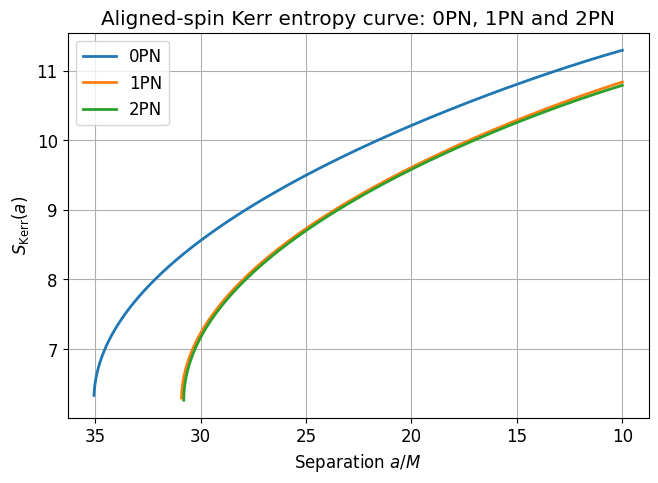

In [9]:
plt.figure()

plt.plot(
    curve_0PN["a"],
    curve_0PN["S_Kerr_0PN"],
    label="0PN"
)

plt.plot(
    curve_1PN["a"],
    curve_1PN["S_Kerr_1PN"],
    label="1PN"
)

plt.plot(
    curve_2PN["a"],
    curve_2PN["S_Kerr_2PN"],
    label="2PN"
)

plt.xlabel(r"Separation $a/M$")
plt.ylabel(r"$S_{\rm Kerr}(a)$")
plt.title("Aligned-spin Kerr entropy curve: 0PN, 1PN and 2PN")
plt.legend()

plt.gca().invert_xaxis()

plt.show()

In [11]:
def pade_2_1(v, p0, p1, p2, q1):
    v = np.asarray(v, dtype=float)
    return (p0 + p1*v + p2*v**2) / (1.0 + q1*v)

def fit_pade_2_1(v_data, y_data, y_name="y"):
    v_data = np.asarray(v_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)

    valid = np.isfinite(v_data) & np.isfinite(y_data)

    v_fit = v_data[valid]
    y_fit = y_data[valid]

    if len(v_fit) < 5:
        raise RuntimeError(f"Not enough valid points to fit {y_name}.")

    p2_guess, p1_guess, p0_guess = np.polyfit(v_fit, y_fit, deg=2)

    initial_guess = [
        p0_guess,
        p1_guess,
        p2_guess,
        0.0
    ]

    popt, pcov = curve_fit(
        pade_2_1,
        v_fit,
        y_fit,
        p0=initial_guess,
        maxfev=50000
    )

    return popt, pcov

def extrapolate_entropy_maximum_for_order(
    curve,
    order_label,
    M_col,
    J_col,
    S_col,
    chi_col,
    a_merger,
    a_fit_min=10.0,
    a_fit_max=40.0,
    a_ext_min=1.0,
    a_ext_max=10.0,
    n_ext=3000
):
   
    fit_mask = (
        np.isfinite(curve["a"])
        &
        np.isfinite(curve[M_col])
        &
        np.isfinite(curve[J_col])
        &
        np.isfinite(curve[S_col])
        &
        (curve["a"] >= a_fit_min)
        &
        (curve["a"] <= a_fit_max)
    )

    fit_data = curve.loc[fit_mask].copy()

    if len(fit_data) < 5:
        raise RuntimeError(
            f"{order_label}: not enough points in the fit window."
        )

    fit_data["v"] = 1.0 / np.sqrt(fit_data["a"])
    fit_data = fit_data.sort_values("v").reset_index(drop=True)

    v_fit = fit_data["v"].to_numpy()
    M_fit = fit_data[M_col].to_numpy()
    J_fit = fit_data[J_col].to_numpy()

    popt_M, pcov_M = fit_pade_2_1(
        v_fit,
        M_fit,
        y_name=f"{order_label} M"
    )

    popt_J, pcov_J = fit_pade_2_1(
        v_fit,
        J_fit,
        y_name=f"{order_label} J"
    )

    a_ext = np.linspace(a_ext_max, a_ext_min, n_ext)
    v_ext = 1.0 / np.sqrt(a_ext)

    M_ext = pade_2_1(v_ext, *popt_M)
    J_ext = pade_2_1(v_ext, *popt_J)

    S_ext, chi_ext = kerr_entropy(
        M_ext,
        J_ext,
        return_chi=True
    )

    physical_mask = (
        np.isfinite(a_ext)
        &
        np.isfinite(M_ext)
        &
        np.isfinite(J_ext)
        &
        np.isfinite(S_ext)
        &
        np.isfinite(chi_ext)
        &
        (M_ext > 0.0)
        &
        (np.abs(chi_ext) <= 1.0)
    )

    if not np.any(physical_mask):
        raise RuntimeError(
            f"{order_label}: no physical points in the extrapolated region."
        )

    a_phys = a_ext[physical_mask]
    M_phys = M_ext[physical_mask]
    J_phys = J_ext[physical_mask]
    S_phys = S_ext[physical_mask]
    chi_phys = chi_ext[physical_mask]

    idx_star = int(np.nanargmax(S_phys))

    a_star = a_phys[idx_star]
    M_star = M_phys[idx_star]
    J_star = J_phys[idx_star]
    chi_star = chi_phys[idx_star]
    S_star = S_phys[idx_star]

    delta_a = a_star - a_merger
    rel_delta_a = delta_a / a_merger

    extrapolation_df = pd.DataFrame({
        "a": a_ext,
        "v": v_ext,
        "M_ext": M_ext,
        "J_ext": J_ext,
        "chi_ext": chi_ext,
        "S_ext": S_ext,
        "physical": physical_mask,
        "PN_order": order_label,
    })

    result = {
        "PN_order": order_label,

        "a_star": a_star,
        "M_star": M_star,
        "J_star": J_star,
        "chi_star": chi_star,
        "S_star": S_star,

        "a_merger": a_merger,
        "delta_a": delta_a,
        "abs_delta_a": abs(delta_a),
        "relative_delta_a": rel_delta_a,
        "abs_relative_delta_a": abs(rel_delta_a),

        "popt_M": popt_M,
        "popt_J": popt_J,

        "a_fit_min": a_fit_min,
        "a_fit_max": a_fit_max,
        "a_ext_min": a_ext_min,
        "a_ext_max": a_ext_max,

        "fit_data": fit_data,
        "extrapolation": extrapolation_df,
    }

    return result

pn_orders = [
    {
        "label": "0PN",
        "curve": curve_0PN,
        "M_col": "M_tot_0PN",
        "J_col": "J_tot_abs_0PN",
        "S_col": "S_Kerr_0PN",
        "chi_col": "chi_Kerr_0PN",
    },
    {
        "label": "1PN",
        "curve": curve_1PN,
        "M_col": "M_tot_1PN",
        "J_col": "J_tot_abs_1PN",
        "S_col": "S_Kerr_1PN",
        "chi_col": "chi_Kerr_1PN",
    },
    {
        "label": "2PN",
        "curve": curve_2PN,
        "M_col": "M_tot_2PN",
        "J_col": "J_tot_abs_2PN",
        "S_col": "S_Kerr_2PN",
        "chi_col": "chi_Kerr_2PN",
    },
]

pade_results = {}
summary_rows = []

for item in pn_orders:
    label = item["label"]


    result = extrapolate_entropy_maximum_for_order(
        curve=item["curve"],
        order_label=label,
        M_col=item["M_col"],
        J_col=item["J_col"],
        S_col=item["S_col"],
        chi_col=item["chi_col"],
        a_merger=a_merger,
        a_fit_min=10.0,
        a_fit_max=40.0,
        a_ext_min=1.0,
        a_ext_max=10.0,
        n_ext=3000
    )

    pade_results[label] = result

    summary_rows.append({
        "PN_order": label,
        "a_star": result["a_star"],
        "a_merger": result["a_merger"],
        "delta_a": result["delta_a"],
        "abs_delta_a": result["abs_delta_a"],
        "relative_delta_a": result["relative_delta_a"],
        "abs_relative_delta_a": result["abs_relative_delta_a"],
        "M_star": result["M_star"],
        "J_star": result["J_star"],
        "chi_star": result["chi_star"],
        "S_star": result["S_star"],
    })

delta_a_summary = pd.DataFrame(summary_rows)

display(delta_a_summary)

/home/giacomo/Thesis/Entropy-conjecture/.venv/lib/python3.12/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


,PN_order,a_star,a_merger,delta_a,abs_delta_a,relative_delta_a,abs_relative_delta_a,M_star,J_star,chi_star,S_star
0,0PN,4.457152,3.373162,1.083990,1.083990,0.321357,0.321357,0.982051,0.385792,0.400022,11.613370
1,1PN,3.556852,3.373162,0.183690,0.183690,0.054456,0.054456,0.985752,0.519429,0.534553,11.265307
2,2PN,4.178059,3.373162,0.804897,0.804897,0.238618,0.238618,0.987168,0.557336,0.571920,11.145685


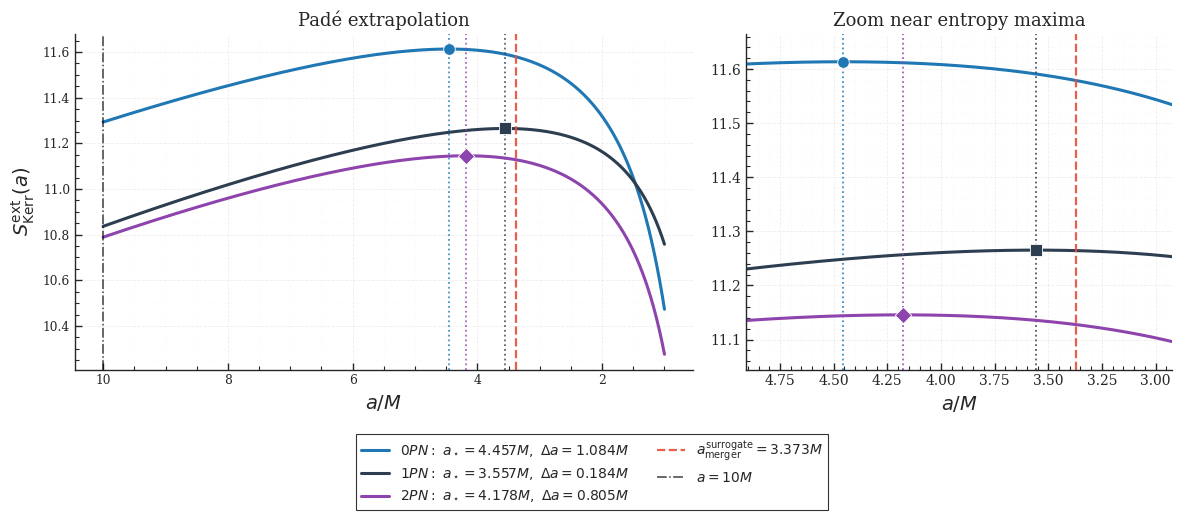

In [12]:
sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

pn_labels = ["0PN", "1PN", "2PN"]

curve_colors = {
    "0PN": "#1f77b4",
    "1PN": "#2c3e50",
    "2PN": "#8e44ad",
}

markers = {
    "0PN": "o",
    "1PN": "s",
    "2PN": "D",
}

fig, (ax, axz) = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    gridspec_kw={"width_ratios": [1.45, 1.0]}
)

curve_data = {}
focus_a_values = [a_merger]


for pn_label in pn_labels:

    result = pade_results[pn_label]
    extrap = result["extrapolation"]

    a_pade = extrap["a"].to_numpy()
    S_pade = extrap["S_ext"].to_numpy()

    a_star = result["a_star"]
    delta_a = result["delta_a"]

    sort_idx = np.argsort(a_pade)
    a_sorted = a_pade[sort_idx]
    S_sorted = S_pade[sort_idx]

    valid_interp_mask = (
        np.isfinite(a_sorted)
        &
        np.isfinite(S_sorted)
    )

    a_sorted_valid = a_sorted[valid_interp_mask]
    S_sorted_valid = S_sorted[valid_interp_mask]

    y_at_star = np.interp(
        a_star,
        a_sorted_valid,
        S_sorted_valid
    )

    curve_data[pn_label] = {
        "a": a_pade,
        "S": S_pade,
        "a_sorted_valid": a_sorted_valid,
        "S_sorted_valid": S_sorted_valid,
        "a_star": a_star,
        "y_star": y_at_star,
        "delta_a": delta_a,
    }

    focus_a_values.append(a_star)

    label_i = (
        fr"${pn_label}:\ "
        fr"a_\star={a_star:.3f}M,\ "
        fr"\Delta a={delta_a:.3f}M$"
    )

    ax.plot(
        a_pade,
        S_pade,
        color=curve_colors[pn_label],
        lw=2.2,
        label=label_i
    )

    ax.scatter(
        a_star,
        y_at_star,
        marker=markers[pn_label],
        s=70,
        color=curve_colors[pn_label],
        zorder=5,
        edgecolor="white",
        linewidth=0.6
    )

    ax.axvline(
        a_star,
        color=curve_colors[pn_label],
        linestyle=":",
        lw=1.3,
        alpha=0.8
    )

ax.axvline(
    a_merger,
    color="#e74c3c",
    linestyle="--",
    lw=1.6,
    alpha=0.9,
    label=fr"$a_{{\rm merger}}^{{\rm surrogate}}={a_merger:.3f}M$"
)

ax.axvline(
    10.0,
    color="black",
    linestyle="-.",
    lw=1.1,
    alpha=0.75,
    label=r"$a=10M$"
)

ax.invert_xaxis()
ax.set_xlabel(r"$a/M$")
ax.set_ylabel(r"$S_{\rm Kerr}^{\rm ext}(a)$")
ax.set_title("Padé extrapolation")

a_focus_min = min(focus_a_values)
a_focus_max = max(focus_a_values)

x_margin = 0.45
x_low = a_focus_min - x_margin
x_high = a_focus_max + x_margin

y_focus_values = []

for pn_label in pn_labels:

    a_vals = curve_data[pn_label]["a_sorted_valid"]
    S_vals = curve_data[pn_label]["S_sorted_valid"]

    focus_mask = (
        (a_vals >= x_low)
        &
        (a_vals <= x_high)
    )

    y_focus_values.extend(S_vals[focus_mask])

y_focus_values = np.asarray(y_focus_values, dtype=float)

if len(y_focus_values) == 0 or not np.any(np.isfinite(y_focus_values)):
    raise RuntimeError(
        "No finite entropy values found in the zoom region. "
        "Try increasing x_margin."
    )

ymin_focus = np.nanmin(y_focus_values)
ymax_focus = np.nanmax(y_focus_values)

if np.isclose(ymax_focus, ymin_focus):
    y_margin = 0.01 * abs(ymax_focus)
else:
    y_margin = 0.10 * (ymax_focus - ymin_focus)

for pn_label in pn_labels:

    axz.plot(
        curve_data[pn_label]["a"],
        curve_data[pn_label]["S"],
        color=curve_colors[pn_label],
        lw=2.2
    )

    axz.scatter(
        curve_data[pn_label]["a_star"],
        curve_data[pn_label]["y_star"],
        marker=markers[pn_label],
        s=70,
        color=curve_colors[pn_label],
        zorder=5,
        edgecolor="white",
        linewidth=0.6
    )

    axz.axvline(
        curve_data[pn_label]["a_star"],
        color=curve_colors[pn_label],
        linestyle=":",
        lw=1.3,
        alpha=0.85
    )

axz.axvline(
    a_merger,
    color="#e74c3c",
    linestyle="--",
    lw=1.6,
    alpha=0.9
)

axz.axvline(
    10.0,
    color="black",
    linestyle="-.",
    lw=1.1,
    alpha=0.75
)

axz.set_xlim(x_high, x_low)
axz.set_ylim(ymin_focus - y_margin, ymax_focus + y_margin)
axz.set_xlabel(r"$a/M$")
axz.set_title("Zoom near entropy maxima")
axz.tick_params(axis="both", labelsize=10)


for axis in [ax, axz]:
    axis.minorticks_on()
    axis.grid(
        True,
        which="major",
        linestyle="--",
        linewidth=0.6,
        alpha=0.35
    )
    axis.grid(
        True,
        which="minor",
        linestyle=":",
        linewidth=0.4,
        alpha=0.18
    )

handles, labels = ax.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    frameon=True,
    shadow=False,
    fancybox=False,
    edgecolor="black",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=2
)

sns.despine()

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()

Taylor

In [13]:
def taylor_model_scaled(v, coeffs, v_center, v_scale):

    v = np.asarray(v, dtype=float)
    z = (v - v_center) / v_scale

    y = np.zeros_like(z, dtype=float)

    for k, ck in enumerate(coeffs):
        y += ck * z**k

    return y

def fit_taylor_scaled(v_data, y_data, degree=3, y_name="y"):


    v_data = np.asarray(v_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)

    valid = (
        np.isfinite(v_data)
        &
        np.isfinite(y_data)
    )

    v_fit = v_data[valid]
    y_fit = y_data[valid]

    if len(v_fit) <= degree + 1:
        raise RuntimeError(
            f"Not enough valid points to fit {y_name} "
            f"with Taylor degree {degree}."
        )

    v_center = np.mean(v_fit)
    v_scale = np.std(v_fit)

    if not np.isfinite(v_scale) or v_scale == 0.0:
        raise RuntimeError(f"Invalid v_scale while fitting {y_name}.")

    z_fit = (v_fit - v_center) / v_scale

    coeffs = np.polynomial.polynomial.polyfit(
        z_fit,
        y_fit,
        deg=degree
    )

    return coeffs, v_center, v_scale

def extrapolate_entropy_maximum_taylor_for_order(
    curve,
    order_label,
    M_col,
    J_col,
    S_col,
    chi_col,
    a_merger,
    degree=3,
    a_fit_min=10.0,
    a_fit_max=40.0,
    a_ext_min=1.0,
    a_ext_max=10.0,
    n_ext=3000
):
 
    fit_mask = (
        np.isfinite(curve["a"])
        &
        np.isfinite(curve[M_col])
        &
        np.isfinite(curve[J_col])
        &
        np.isfinite(curve[S_col])
        &
        (curve["a"] >= a_fit_min)
        &
        (curve["a"] <= a_fit_max)
    )

    fit_data = curve.loc[fit_mask].copy()

    if len(fit_data) <= degree + 1:
        raise RuntimeError(
            f"{order_label}: not enough points in the fit window "
            f"for Taylor degree {degree}."
        )

    fit_data["v"] = 1.0 / np.sqrt(fit_data["a"])
    fit_data = fit_data.sort_values("v").reset_index(drop=True)

    v_fit = fit_data["v"].to_numpy()
    M_fit = fit_data[M_col].to_numpy()
    J_fit = fit_data[J_col].to_numpy()

    coeffs_M, v_center_M, v_scale_M = fit_taylor_scaled(
        v_fit,
        M_fit,
        degree=degree,
        y_name=f"{order_label} M"
    )

    coeffs_J, v_center_J, v_scale_J = fit_taylor_scaled(
        v_fit,
        J_fit,
        degree=degree,
        y_name=f"{order_label} J"
    )


    a_ext = np.linspace(a_ext_max, a_ext_min, n_ext)
    v_ext = 1.0 / np.sqrt(a_ext)

    M_ext = taylor_model_scaled(
        v_ext,
        coeffs_M,
        v_center_M,
        v_scale_M
    )

    J_ext = taylor_model_scaled(
        v_ext,
        coeffs_J,
        v_center_J,
        v_scale_J
    )

    S_ext, chi_ext = kerr_entropy(
        M_ext,
        J_ext,
        return_chi=True
    )

    physical_mask = (
        np.isfinite(a_ext)
        &
        np.isfinite(M_ext)
        &
        np.isfinite(J_ext)
        &
        np.isfinite(S_ext)
        &
        np.isfinite(chi_ext)
        &
        (M_ext > 0.0)
        &
        (np.abs(chi_ext) <= 1.0)
    )

    if not np.any(physical_mask):
        raise RuntimeError(
            f"{order_label}: no physical points in the extrapolated region."
        )

    a_phys = a_ext[physical_mask]
    M_phys = M_ext[physical_mask]
    J_phys = J_ext[physical_mask]
    S_phys = S_ext[physical_mask]
    chi_phys = chi_ext[physical_mask]

    idx_star = int(np.nanargmax(S_phys))

    a_star = a_phys[idx_star]
    M_star = M_phys[idx_star]
    J_star = J_phys[idx_star]
    chi_star = chi_phys[idx_star]
    S_star = S_phys[idx_star]

    delta_a = a_star - a_merger
    rel_delta_a = delta_a / a_merger

    extrapolation_df = pd.DataFrame({
        "a": a_ext,
        "v": v_ext,
        "M_extrap": M_ext,
        "J_extrap": J_ext,
        "chi_extrap": chi_ext,
        "ENT_extrap": S_ext,
        "physical": physical_mask,
        "PN_order": order_label,
    })

    result = {
        "PN_order": order_label,

        "a_max": a_star,
        "a_star": a_star,

        "M_star": M_star,
        "J_star": J_star,
        "chi_star": chi_star,
        "S_star": S_star,

        "a_merger": a_merger,
        "delta_a": delta_a,
        "abs_delta_a": abs(delta_a),
        "relative_delta_a": rel_delta_a,
        "abs_relative_delta_a": abs(rel_delta_a),

        "degree": degree,

        "coeffs_M": coeffs_M,
        "coeffs_J": coeffs_J,

        "v_center_M": v_center_M,
        "v_scale_M": v_scale_M,
        "v_center_J": v_center_J,
        "v_scale_J": v_scale_J,

        "a_fit_min": a_fit_min,
        "a_fit_max": a_fit_max,
        "a_ext_min": a_ext_min,
        "a_ext_max": a_ext_max,

        "fit_data": fit_data,
        "extrapolation": extrapolation_df,
    }

    return result

taylor_degree = 3

pn_orders = [
    {
        "label": "0PN",
        "curve": curve_0PN,
        "M_col": "M_tot_0PN",
        "J_col": "J_tot_abs_0PN",
        "S_col": "S_Kerr_0PN",
        "chi_col": "chi_Kerr_0PN",
    },
    {
        "label": "1PN",
        "curve": curve_1PN,
        "M_col": "M_tot_1PN",
        "J_col": "J_tot_abs_1PN",
        "S_col": "S_Kerr_1PN",
        "chi_col": "chi_Kerr_1PN",
    },
    {
        "label": "2PN",
        "curve": curve_2PN,
        "M_col": "M_tot_2PN",
        "J_col": "J_tot_abs_2PN",
        "S_col": "S_Kerr_2PN",
        "chi_col": "chi_Kerr_2PN",
    },
]

taylor_results_all = {}
taylor_curves_all = {}
summary_rows_taylor = []

for item in pn_orders:

    label = item["label"]

    result = extrapolate_entropy_maximum_taylor_for_order(
        curve=item["curve"],
        order_label=label,
        M_col=item["M_col"],
        J_col=item["J_col"],
        S_col=item["S_col"],
        chi_col=item["chi_col"],
        a_merger=a_merger,
        degree=taylor_degree,
        a_fit_min=10.0,
        a_fit_max=40.0,
        a_ext_min=2.0,
        a_ext_max=10.0,
        n_ext=10000
    )

    taylor_results_all[label] = result

    taylor_curves_all[label] = {
        "a_extrap": result["extrapolation"]["a"].to_numpy(),
        "M_extrap": result["extrapolation"]["M_extrap"].to_numpy(),
        "J_extrap": result["extrapolation"]["J_extrap"].to_numpy(),
        "chi_extrap": result["extrapolation"]["chi_extrap"].to_numpy(),
        "ENT_extrap": result["extrapolation"]["ENT_extrap"].to_numpy(),
        "physical": result["extrapolation"]["physical"].to_numpy(),
    }

    summary_rows_taylor.append({
        "PN_order": label,
        "degree": result["degree"],
        "a_max": result["a_max"],
        "a_star": result["a_star"],
        "a_merger": result["a_merger"],
        "delta_a": result["delta_a"],
        "abs_delta_a": result["abs_delta_a"],
        "relative_delta_a": result["relative_delta_a"],
        "abs_relative_delta_a": result["abs_relative_delta_a"],
        "M_star": result["M_star"],
        "J_star": result["J_star"],
        "chi_star": result["chi_star"],
        "S_star": result["S_star"],
    })


results_taylor_all_df = pd.DataFrame(summary_rows_taylor)

print()
print("============================================================")
print("Summary: Taylor extrapolation, delta_a by PN order")
print("============================================================")

display(results_taylor_all_df)


Summary: Taylor extrapolation, delta_a by PN order


,PN_order,degree,a_max,a_star,a_merger,delta_a,abs_delta_a,relative_delta_a,abs_relative_delta_a,M_star,J_star,chi_star,S_star
0,0PN,3,4.456246,4.456246,3.373162,1.083084,1.083084,0.321089,0.321089,0.982048,0.048088,0.049862,12.111692
1,1PN,3,3.720972,3.720972,3.373162,0.347810,0.347810,0.103111,0.103111,0.987651,0.009832,0.010080,12.257613
2,2PN,3,3.636964,3.636964,3.373162,0.263802,0.263802,0.078206,0.078206,0.987361,0.009993,0.010250,12.250407


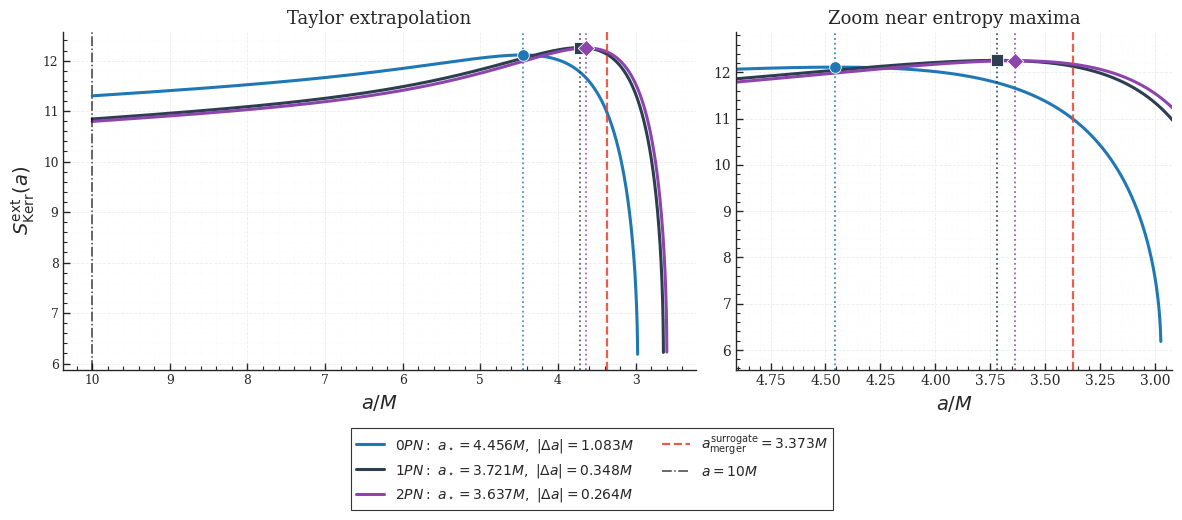

In [14]:
sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

pn_labels = ["0PN", "1PN", "2PN"]

curve_colors = {
    "0PN": "#1f77b4",
    "1PN": "#2c3e50",
    "2PN": "#8e44ad",
}

markers = {
    "0PN": "o",
    "1PN": "s",
    "2PN": "D",
}


if "abs_delta_a" not in results_taylor_all_df.columns:
    results_taylor_all_df["abs_delta_a"] = np.abs(
        results_taylor_all_df["delta_a"]
    )

if "abs_relative_delta_a" not in results_taylor_all_df.columns:
    results_taylor_all_df["abs_relative_delta_a"] = np.abs(
        results_taylor_all_df["relative_delta_a"]
    )

fig, (ax, axz) = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    gridspec_kw={"width_ratios": [1.45, 1.0]}
)

curve_data = {}
focus_a_values = [a_merger]

for pn_label in pn_labels:

    row = results_taylor_all_df.loc[
        results_taylor_all_df["PN_order"] == pn_label
    ].iloc[0]

    a_taylor = taylor_curves_all[pn_label]["a_extrap"]
    S_taylor = taylor_curves_all[pn_label]["ENT_extrap"]

    a_star = row["a_max"]
    abs_delta_a = row["abs_delta_a"]

    sort_idx = np.argsort(a_taylor)

    a_sorted = a_taylor[sort_idx]
    S_sorted = S_taylor[sort_idx]

    valid_interp_mask = (
        np.isfinite(a_sorted)
        &
        np.isfinite(S_sorted)
    )

    a_sorted_valid = a_sorted[valid_interp_mask]
    S_sorted_valid = S_sorted[valid_interp_mask]

    y_at_star = np.interp(
        a_star,
        a_sorted_valid,
        S_sorted_valid
    )

    curve_data[pn_label] = {
        "a": a_taylor,
        "S": S_taylor,
        "a_sorted_valid": a_sorted_valid,
        "S_sorted_valid": S_sorted_valid,
        "a_star": a_star,
        "y_star": y_at_star,
        "abs_delta_a": abs_delta_a,
    }

    focus_a_values.append(a_star)

    label_i = (
        fr"${pn_label}:\ "
        fr"a_\star={a_star:.3f}M,\ "
        fr"|\Delta a|={abs_delta_a:.3f}M$"
    )

    ax.plot(
        a_taylor,
        S_taylor,
        color=curve_colors[pn_label],
        lw=2.2,
        label=label_i
    )

    ax.scatter(
        a_star,
        y_at_star,
        marker=markers[pn_label],
        s=70,
        color=curve_colors[pn_label],
        zorder=5,
        edgecolor="white",
        linewidth=0.6
    )

    ax.axvline(
        a_star,
        color=curve_colors[pn_label],
        linestyle=":",
        lw=1.3,
        alpha=0.8
    )

ax.axvline(
    a_merger,
    color="#e74c3c",
    linestyle="--",
    lw=1.6,
    alpha=0.9,
    label=fr"$a_{{\rm merger}}^{{\rm surrogate}}={a_merger:.3f}M$"
)

ax.axvline(
    10.0,
    color="black",
    linestyle="-.",
    lw=1.1,
    alpha=0.75,
    label=r"$a=10M$"
)

ax.invert_xaxis()
ax.set_xlabel(r"$a/M$")
ax.set_ylabel(r"$S_{\rm Kerr}^{\rm ext}(a)$")
ax.set_title("Taylor extrapolation")

a_focus_min = min(focus_a_values)
a_focus_max = max(focus_a_values)

x_margin = 0.45

x_low = a_focus_min - x_margin
x_high = a_focus_max + x_margin

y_focus_values = []

for pn_label in pn_labels:

    a_vals = curve_data[pn_label]["a_sorted_valid"]
    S_vals = curve_data[pn_label]["S_sorted_valid"]

    focus_mask = (
        (a_vals >= x_low)
        &
        (a_vals <= x_high)
    )

    y_focus_values.extend(S_vals[focus_mask])

y_focus_values = np.asarray(y_focus_values, dtype=float)

if len(y_focus_values) == 0 or not np.any(np.isfinite(y_focus_values)):
    raise RuntimeError(
        "No finite entropy values found in the zoom region. "
        "Try increasing x_margin."
    )

ymin_focus = np.nanmin(y_focus_values)
ymax_focus = np.nanmax(y_focus_values)

if np.isclose(ymax_focus, ymin_focus):
    y_margin = 0.01 * abs(ymax_focus)
else:
    y_margin = 0.10 * (ymax_focus - ymin_focus)

for pn_label in pn_labels:

    axz.plot(
        curve_data[pn_label]["a"],
        curve_data[pn_label]["S"],
        color=curve_colors[pn_label],
        lw=2.2
    )

    axz.scatter(
        curve_data[pn_label]["a_star"],
        curve_data[pn_label]["y_star"],
        marker=markers[pn_label],
        s=70,
        color=curve_colors[pn_label],
        zorder=5,
        edgecolor="white",
        linewidth=0.6
    )

    axz.axvline(
        curve_data[pn_label]["a_star"],
        color=curve_colors[pn_label],
        linestyle=":",
        lw=1.3,
        alpha=0.85
    )

axz.axvline(
    a_merger,
    color="#e74c3c",
    linestyle="--",
    lw=1.6,
    alpha=0.9
)

axz.axvline(
    10.0,
    color="black",
    linestyle="-.",
    lw=1.1,
    alpha=0.75
)

axz.set_xlim(x_high, x_low)
axz.set_ylim(ymin_focus - y_margin, ymax_focus + y_margin)

axz.set_xlabel(r"$a/M$")
axz.set_title("Zoom near entropy maxima")
axz.tick_params(axis="both", labelsize=10)

for axis in [ax, axz]:

    axis.minorticks_on()

    axis.grid(
        True,
        which="major",
        linestyle="--",
        linewidth=0.6,
        alpha=0.35
    )

    axis.grid(
        True,
        which="minor",
        linestyle=":",
        linewidth=0.4,
        alpha=0.18
    )

handles, labels = ax.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    frameon=True,
    shadow=False,
    fancybox=False,
    edgecolor="black",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=2
)

sns.despine()

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()

SPIN HEATMAPS

In [15]:
master_data_dir = Path("data/aligned_spin_analysis")
master_data_dir.mkdir(parents=True, exist_ok=True)

MASTER_HEATMAP_PATH = master_data_dir / "master_aligned_spin_heatmap_results.csv"

def update_master_heatmap_results(
    current_df,
    method,
    q_value=None,
    master_path=MASTER_HEATMAP_PATH,
    overwrite_same_grid=True
):


    df_new = current_df.copy()

    df_new["method"] = method

    if "q" not in df_new.columns:
        if q_value is None:
            raise ValueError("q_value must be provided if current_df has no 'q' column.")
        df_new["q"] = float(q_value)

    required_cols = [
        "method",
        "q",
        "chi1_z",
        "chi2_z",
        "PN_order",
        "a_star",
        "a_merger",
        "abs_delta_a",
    ]

    missing = [
        col for col in required_cols
        if col not in df_new.columns
    ]

    if missing:
        raise KeyError(f"Missing columns in current_df: {missing}")

    for col in ["q", "chi1_z", "chi2_z", "a_star", "a_merger", "abs_delta_a"]:
        df_new[col] = pd.to_numeric(
            df_new[col],
            errors="coerce"
        )

    if "delta_a_signed" not in df_new.columns:
        df_new["delta_a_signed"] = (
            df_new["a_star"]
            -
            df_new["a_merger"]
        )
    else:
        df_new["delta_a_signed"] = pd.to_numeric(
            df_new["delta_a_signed"],
            errors="coerce"
        )

    df_new["abs_delta_a"] = np.abs(df_new["delta_a_signed"])
    df_new["q_key"] = np.round(df_new["q"].astype(float), 12)
    df_new["chi1_key"] = np.round(df_new["chi1_z"].astype(float), 12)
    df_new["chi2_key"] = np.round(df_new["chi2_z"].astype(float), 12)

    df_new["updated_at"] = datetime.now().isoformat(timespec="seconds")

    if master_path.exists():
        df_old = pd.read_csv(master_path)
    else:
        df_old = pd.DataFrame()

    if len(df_old) > 0:
        for col in ["q", "chi1_z", "chi2_z", "a_star", "a_merger", "abs_delta_a"]:
            if col in df_old.columns:
                df_old[col] = pd.to_numeric(
                    df_old[col],
                    errors="coerce"
                )

        if "q_key" not in df_old.columns:
            df_old["q_key"] = np.round(df_old["q"].astype(float), 12)

        if "chi1_key" not in df_old.columns:
            df_old["chi1_key"] = np.round(df_old["chi1_z"].astype(float), 12)

        if "chi2_key" not in df_old.columns:
            df_old["chi2_key"] = np.round(df_old["chi2_z"].astype(float), 12)

        df_master = pd.concat(
            [df_old, df_new],
            ignore_index=True
        )
    else:
        df_master = df_new.copy()

    if overwrite_same_grid:
        df_master = (
            df_master
            .sort_values("updated_at")
            .drop_duplicates(
                subset=[
                    "method",
                    "q_key",
                    "chi1_key",
                    "chi2_key",
                    "PN_order",
                ],
                keep="last"
            )
            .reset_index(drop=True)
        )

    df_master.to_csv(
        master_path,
        index=False
    )

    print()
    print("Master heatmap dataframe updated.")
    print("---------------------------------")
    print(f"Saved to: {master_path}")
    print(f"Total rows: {len(df_master)}")
    print("Available mass ratios:")
    print(sorted(df_master["q"].dropna().unique()))

    return df_master

Padé heatmaps q=0.8:   0%|          | 0/400 [00:00<?, ?it/s]


Master heatmap dataframe updated.
---------------------------------
Saved to: data/aligned_spin_analysis/master_aligned_spin_heatmap_results.csv
Total rows: 28800
Available mass ratios:
[0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]


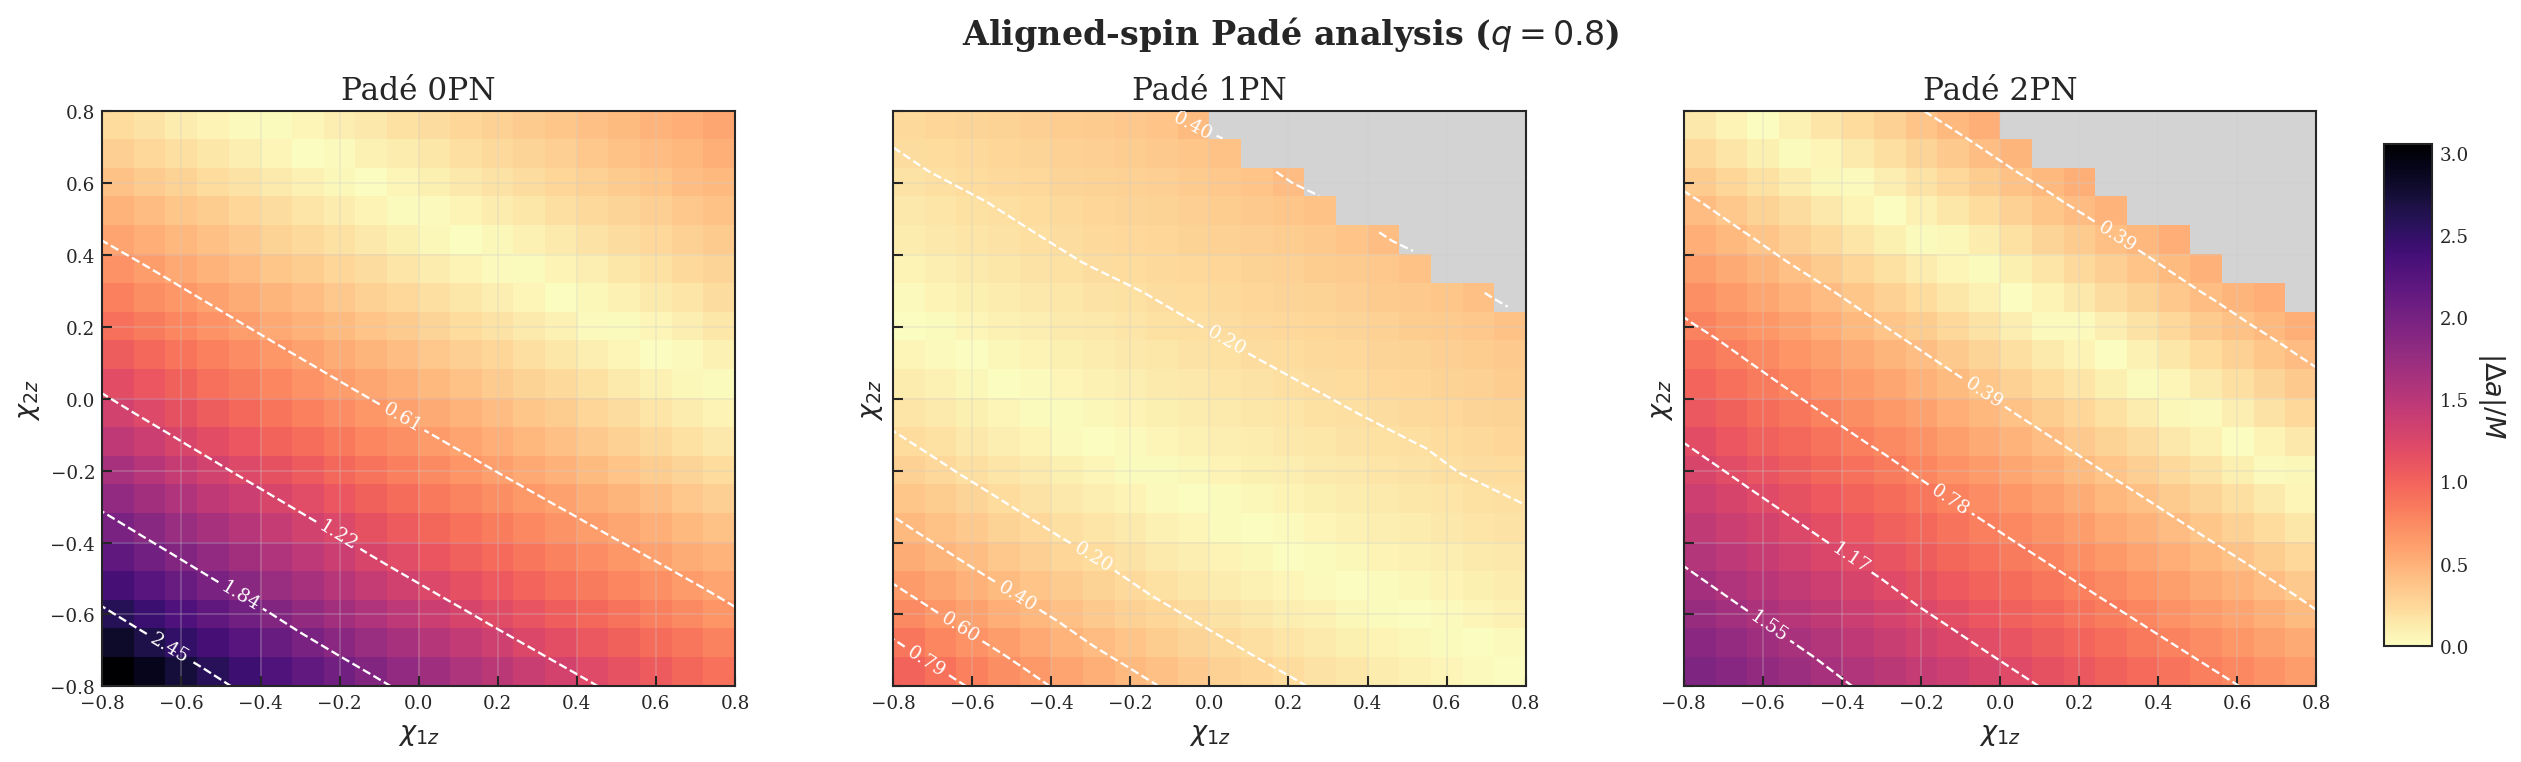

In [16]:
q_pade = 0.8

n_points_p = 20
chi_range_p = np.linspace(-0.8, 0.8, n_points_p)

a_curve = np.linspace(100.0, 10, 1000)

a_fit_min = 10.0
a_fit_max = 40.0

a_extrap_min = 2.0
a_extrap_max = 10.0
n_extrap = 10000

dt_sur = 0.1
f_low_sur = 0.0


plt.rcParams.update({
    "font.family": "serif",
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

def pade_2_1(v, p0, p1, p2, q1):
    v = np.asarray(v, dtype=float)
    return (p0 + p1*v + p2*v**2) / (1.0 + q1*v)

def fit_pade_2_1(v_data, y_data, y_name="y"):
    v_data = np.asarray(v_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)

    valid = (
        np.isfinite(v_data)
        &
        np.isfinite(y_data)
    )

    v_fit = v_data[valid]
    y_fit = y_data[valid]

    if len(v_fit) < 5:
        raise RuntimeError(f"Not enough valid points to fit {y_name}.")

    p2_guess, p1_guess, p0_guess = np.polyfit(v_fit, y_fit, deg=2)

    p0 = [
        p0_guess,
        p1_guess,
        p2_guess,
        0.0
    ]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", OptimizeWarning)

        popt, pcov = curve_fit(
            pade_2_1,
            v_fit,
            y_fit,
            p0=p0,
            maxfev=50000
        )

    return popt, pcov

if "aligned_merger_cache" not in globals():
    aligned_merger_cache = {}

def get_aligned_merger_separation_cached(q_input, chi1_z, chi2_z):
    key = (
        round(float(q_input), 12),
        round(float(chi1_z), 12),
        round(float(chi2_z), 12),
    )

    if key in aligned_merger_cache:
        return aligned_merger_cache[key]

    try:
        merger_result = estimate_merger_separation_from_surrogate(
            q_input=q_input,
            chi1_z=chi1_z,
            chi2_z=chi2_z,
            sur_wave_aligned=sur_wave_aligned,
            a_ref_start=20.0,
            omega_ref_factor=1.05,
            max_attempts=30,
            f_low=f_low_sur,
            dt=dt_sur,
            peak_window=5,
            smooth_frequency=True,
            plot=False
        )

    except TypeError:
        merger_result = estimate_merger_separation_from_surrogate(
            q_input=q_input,
            chi1_z=chi1_z,
            chi2_z=chi2_z,
            sur_wave_aligned=sur_wave_aligned,
            a_ref=20.0,
            f_low=f_low_sur,
            dt=dt_sur,
            peak_window=5,
            smooth_frequency=True,
            plot=False
        )

    a_merger_val = float(merger_result["a_merger"])

    aligned_merger_cache[key] = a_merger_val

    return a_merger_val

def build_aligned_curves_for_heatmap(q_input, chi1_z, chi2_z):
    params = aligned_binary_parameters(
        q_input,
        chi1_z,
        chi2_z
    )

    curve_0PN = aligned_entropy_curve_0PN(
        a_curve,
        params
    )

    curve_1PN = aligned_entropy_curve_1PN(
        a_curve,
        params
    )

    curve_2PN = aligned_entropy_curve_2PN(
        a_curve,
        params
    )

    return {
        "0PN": curve_0PN,
        "1PN": curve_1PN,
        "2PN": curve_2PN,
    }

def get_abs_delta_a_pade_correct(
    curve,
    M_col,
    J_col,
    a_merger
):


    fit_mask = (
        np.isfinite(curve["a"])
        &
        np.isfinite(curve[M_col])
        &
        np.isfinite(curve[J_col])
        &
        (curve["a"] >= a_fit_min)
        &
        (curve["a"] <= a_fit_max)
    )

    fit_data = curve.loc[fit_mask].copy()

    if len(fit_data) < 5:
        raise RuntimeError("Not enough points in the fit region.")

    fit_data["v"] = 1.0 / np.sqrt(fit_data["a"])
    fit_data = fit_data.sort_values("v").reset_index(drop=True)

    v_fit = fit_data["v"].to_numpy()
    M_fit = fit_data[M_col].to_numpy()
    J_fit = fit_data[J_col].to_numpy()

    popt_M, _ = fit_pade_2_1(
        v_fit,
        M_fit,
        y_name=M_col
    )

    popt_J, _ = fit_pade_2_1(
        v_fit,
        J_fit,
        y_name=J_col
    )

    a_extrap = np.linspace(a_extrap_max, a_extrap_min, n_extrap)
    v_extrap = 1.0 / np.sqrt(a_extrap)

    M_extrap = pade_2_1(v_extrap, *popt_M)
    J_extrap = pade_2_1(v_extrap, *popt_J)

    S_extrap, chi_extrap = kerr_entropy(
        M_extrap,
        J_extrap,
        return_chi=True
    )

    physical_mask = (
        np.isfinite(a_extrap)
        &
        np.isfinite(M_extrap)
        &
        np.isfinite(J_extrap)
        &
        np.isfinite(S_extrap)
        &
        np.isfinite(chi_extrap)
        &
        (M_extrap > 0.0)
        &
        (np.abs(chi_extrap) <= 1.0)
    )

    if not np.any(physical_mask):
        raise RuntimeError("No physical points in the extrapolated region.")

    a_phys = a_extrap[physical_mask]
    S_phys = S_extrap[physical_mask]
    M_phys = M_extrap[physical_mask]
    J_phys = J_extrap[physical_mask]
    chi_phys = chi_extrap[physical_mask]

    idx_star = int(np.nanargmax(S_phys))

    a_star = float(a_phys[idx_star])
    M_star = float(M_phys[idx_star])
    J_star = float(J_phys[idx_star])
    chi_star = float(chi_phys[idx_star])
    S_star = float(S_phys[idx_star])

    abs_delta_a = abs(a_star - a_merger)

    return {
        "a_star": a_star,
        "abs_delta_a": abs_delta_a,
        "M_star": M_star,
        "J_star": J_star,
        "chi_star": chi_star,
        "S_star": S_star,
    }


chi1_grid_p, chi2_grid_p = np.meshgrid(chi_range_p,chi_range_p)

delta_r_0PN = np.full_like(chi1_grid_p, np.nan, dtype=float)
delta_r_1PN = np.full_like(chi1_grid_p, np.nan, dtype=float)
delta_r_2PN = np.full_like(chi1_grid_p, np.nan, dtype=float)

a_star_0PN = np.full_like(chi1_grid_p, np.nan, dtype=float)
a_star_1PN = np.full_like(chi1_grid_p, np.nan, dtype=float)
a_star_2PN = np.full_like(chi1_grid_p, np.nan, dtype=float)

a_merger_matrix = np.full_like(chi1_grid_p, np.nan, dtype=float)

failure_rows_pade = []



total_iterations = n_points_p * n_points_p
pbar = tqdm(
    total=total_iterations,
    desc=f"Padé heatmaps q={q_pade}"
)

for i in range(n_points_p):
    for j in range(n_points_p):

        chi1_val = float(chi1_grid_p[i, j])
        chi2_val = float(chi2_grid_p[i, j])

        try:
            a_merger_val = get_aligned_merger_separation_cached(
                q_input=q_pade,
                chi1_z=chi1_val,
                chi2_z=chi2_val
            )

            a_merger_matrix[i, j] = a_merger_val

            curves = build_aligned_curves_for_heatmap(
                q_input=q_pade,
                chi1_z=chi1_val,
                chi2_z=chi2_val
            )

            # 0PN
            out_0PN = get_abs_delta_a_pade_correct(
                curve=curves["0PN"],
                M_col="M_tot_0PN",
                J_col="J_tot_abs_0PN",
                a_merger=a_merger_val
            )

            a_star_0PN[i, j] = out_0PN["a_star"]
            delta_r_0PN[i, j] = out_0PN["abs_delta_a"]

            # 1PN
            out_1PN = get_abs_delta_a_pade_correct(
                curve=curves["1PN"],
                M_col="M_tot_1PN",
                J_col="J_tot_abs_1PN",
                a_merger=a_merger_val
            )

            a_star_1PN[i, j] = out_1PN["a_star"]
            delta_r_1PN[i, j] = out_1PN["abs_delta_a"]

            # 2PN
            out_2PN = get_abs_delta_a_pade_correct(
                curve=curves["2PN"],
                M_col="M_tot_2PN",
                J_col="J_tot_abs_2PN",
                a_merger=a_merger_val
            )

            a_star_2PN[i, j] = out_2PN["a_star"]
            delta_r_2PN[i, j] = out_2PN["abs_delta_a"]

        except Exception as exc:
            failure_rows_pade.append({
                "q": q_pade,
                "chi1_z": chi1_val,
                "chi2_z": chi2_val,
                "error": repr(exc),
            })

        finally:
            pbar.update(1)

pbar.close()

failure_pade_df = pd.DataFrame(failure_rows_pade)

pade_heatmap_records = []

for i in range(n_points_p):
    for j in range(n_points_p):

        chi1_val = float(chi1_grid_p[i, j])
        chi2_val = float(chi2_grid_p[i, j])

        pade_heatmap_records.append({
            "q": q_pade,
            "chi1_z": chi1_val,
            "chi2_z": chi2_val,
            "PN_order": "0PN",
            "a_merger": a_merger_matrix[i, j],
            "a_star": a_star_0PN[i, j],
            "abs_delta_a": delta_r_0PN[i, j],
        })

        pade_heatmap_records.append({
            "q": q_pade,
            "chi1_z": chi1_val,
            "chi2_z": chi2_val,
            "PN_order": "1PN",
            "a_merger": a_merger_matrix[i, j],
            "a_star": a_star_1PN[i, j],
            "abs_delta_a": delta_r_1PN[i, j],
        })

        pade_heatmap_records.append({
            "q": q_pade,
            "chi1_z": chi1_val,
            "chi2_z": chi2_val,
            "PN_order": "2PN",
            "a_merger": a_merger_matrix[i, j],
            "a_star": a_star_2PN[i, j],
            "abs_delta_a": delta_r_2PN[i, j],
        })

pade_heatmap_df = pd.DataFrame(pade_heatmap_records)

master_heatmap_results_df = update_master_heatmap_results(
    current_df=pade_heatmap_df,
    method="Padé",
    q_value=q_pade
)


pn_titles = ["0PN", "1PN", "2PN"]
delta_matrices = [
    delta_r_0PN,
    delta_r_1PN,
    delta_r_2PN,
]

all_delta_values = np.concatenate([
    delta_r_0PN[np.isfinite(delta_r_0PN)],
    delta_r_1PN[np.isfinite(delta_r_1PN)],
    delta_r_2PN[np.isfinite(delta_r_2PN)],
])

if len(all_delta_values) == 0:
    raise RuntimeError("No finite Padé heatmap values were produced.")

vmin = 0.0
vmax = np.nanmax(all_delta_values)

cmap = plt.cm.magma_r.copy()
cmap.set_bad(color="lightgray")

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.4),
    dpi=150,
    sharex=True,
    sharey=True
)

fig.subplots_adjust(
    left=0.06,
    right=0.88,
    bottom=0.13,
    top=0.84,
    wspace=0.25
)

cbar_ax = fig.add_axes([0.905, 0.18, 0.018, 0.62])

last_heatmap = None

for ax, pn_title, delta_matrix in zip(
    axes,
    pn_titles,
    delta_matrices
):

    delta_masked = np.ma.masked_invalid(delta_matrix)

    last_heatmap = ax.imshow(
        delta_masked,
        origin="lower",
        extent=(
            chi_range_p.min(),
            chi_range_p.max(),
            chi_range_p.min(),
            chi_range_p.max()
        ),
        cmap=cmap,
        aspect="auto",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax
    )

    finite_vals = delta_matrix[np.isfinite(delta_matrix)]

    if len(finite_vals) > 1 and not np.isclose(
        np.nanmin(finite_vals),
        np.nanmax(finite_vals)
    ):

        contour_levels = np.linspace(
            np.nanmin(finite_vals),
            np.nanmax(finite_vals),
            6
        )

        contour_levels = contour_levels[
            np.isfinite(contour_levels)
        ]

        if len(np.unique(contour_levels)) >= 2:
            contours = ax.contour(
                chi1_grid_p,
                chi2_grid_p,
                delta_matrix,
                levels=contour_levels,
                colors="white",
                linestyles="--",
                linewidths=1.1
            )

            ax.clabel(
                contours,
                inline=True,
                fontsize=9,
                fmt=r"%.2f"
            )

    ax.set_xlabel(r"$\chi_{1z}$")
    ax.set_ylabel(r"$\chi_{2z}$")
    ax.set_title(rf"Padé {pn_title}")

    ax.set_xlim(chi_range_p.min(), chi_range_p.max())
    ax.set_ylim(chi_range_p.min(), chi_range_p.max())

cbar = fig.colorbar(
    last_heatmap,
    cax=cbar_ax
)

cbar.set_label(
    r"$|\Delta a|/M$",
    rotation=270,
    labelpad=18
)

fig.suptitle(
    rf"Aligned-spin Padé analysis ($q={q_pade}$)",
    fontsize=16,
    fontweight="bold",
    y=0.96
)

output_dir = Path("figures")
output_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    output_dir / f"padè_heatmaps_q_{q_pade:.3f}.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    output_dir / f"padè_heatmaps_q_{q_pade:.3f}.pdf",
    bbox_inches="tight"
)


plt.show()

Taylor heatmaps q=0.8:   0%|          | 0/400 [00:00<?, ?it/s]


Master heatmap dataframe updated.
---------------------------------
Saved to: data/aligned_spin_analysis/master_aligned_spin_heatmap_results.csv
Total rows: 28800
Available mass ratios:
[0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]


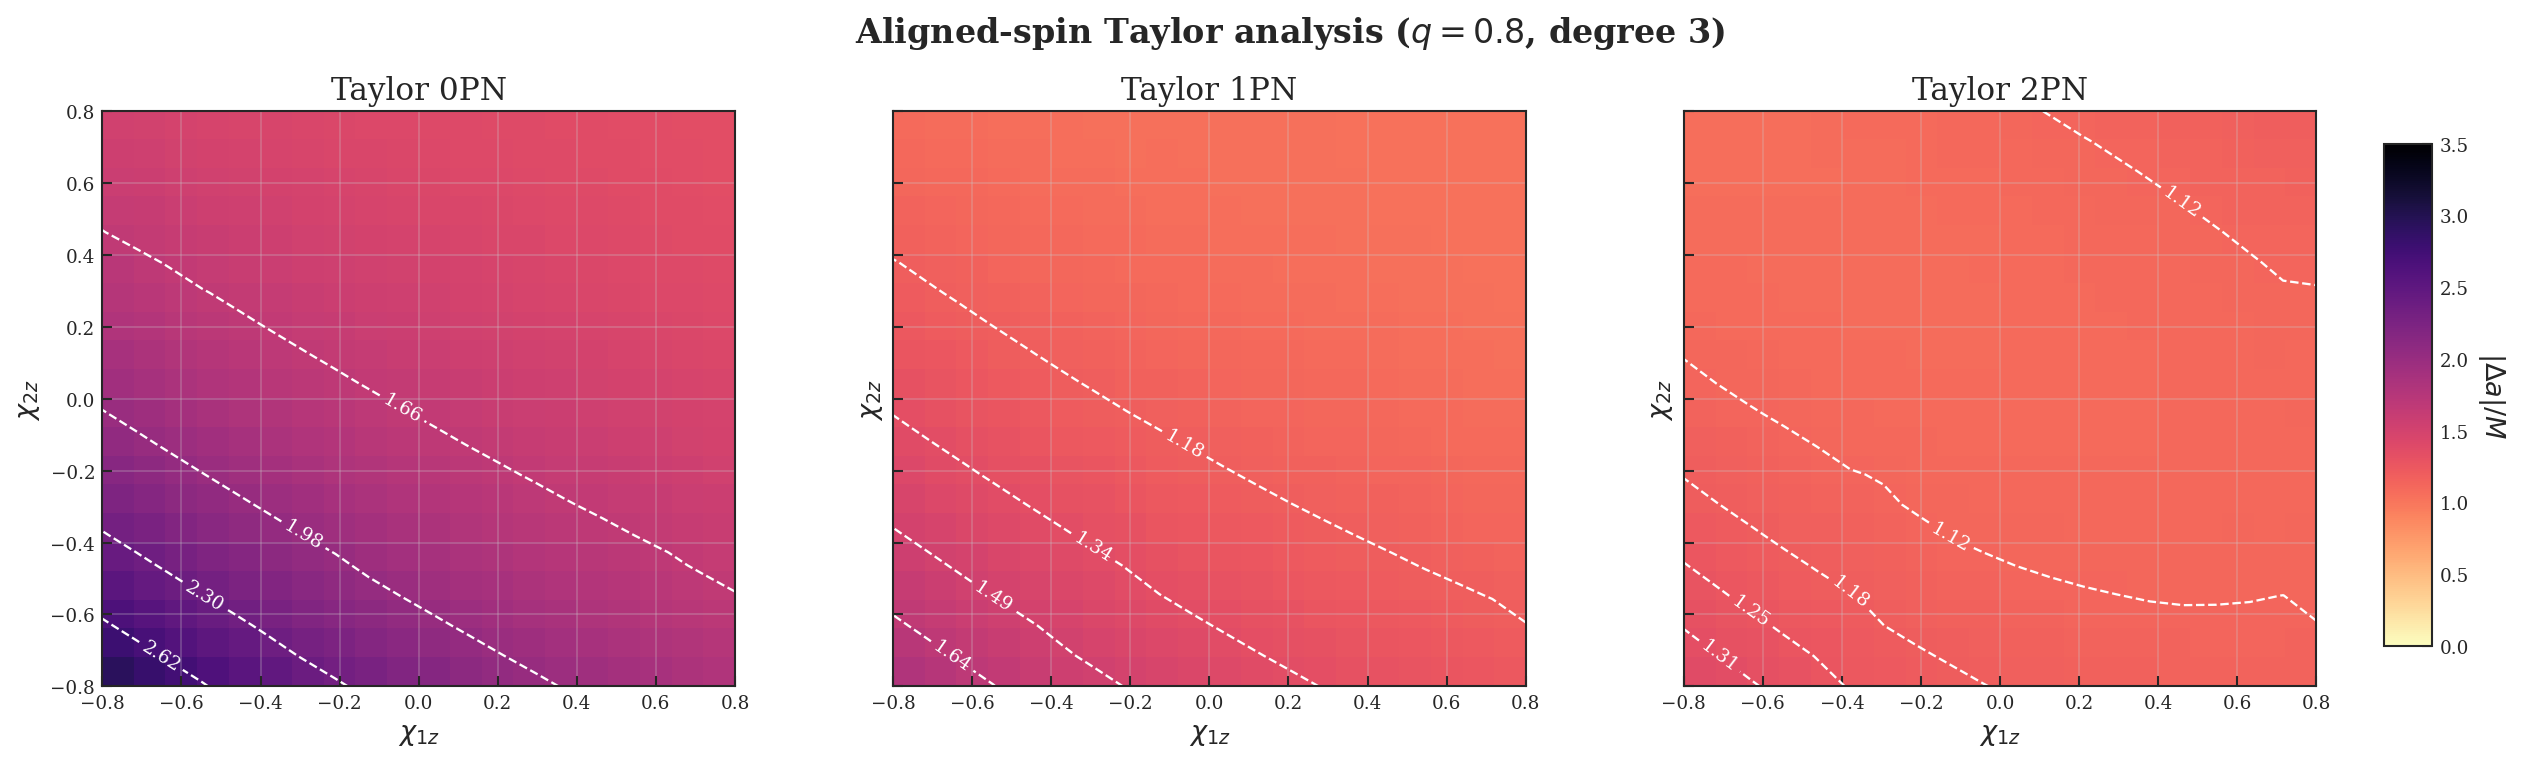

In [17]:
q_taylor = 0.8

n_points_t = 20
chi_range_t = np.linspace(-0.8, 0.8, n_points_t)

a_curve = np.linspace(100.0, 10, 10000)

a_fit_min = 10.0
a_fit_max = 40.0

a_extrap_min = 2.0
a_extrap_max = 10.0
n_extrap = 10000

taylor_degree = 3

dt_sur = 0.1
f_low_sur = 0.0


plt.rcParams.update({
    "font.family": "serif",
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "xtick.direction": "in",
    "ytick.direction": "in",
})


def taylor_model_scaled_heatmap(v, coeffs, v_center, v_scale):

    v = np.asarray(v, dtype=float)
    z = (v - v_center) / v_scale

    y = np.zeros_like(z, dtype=float)

    for k, ck in enumerate(coeffs):
        y += ck * z**k

    return y

def fit_taylor_scaled_heatmap(v_data, y_data, degree=3, y_name="y"):

    v_data = np.asarray(v_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)

    valid = (
        np.isfinite(v_data)
        &
        np.isfinite(y_data)
    )

    v_fit = v_data[valid]
    y_fit = y_data[valid]

    if len(v_fit) <= degree + 1:
        raise RuntimeError(
            f"Not enough valid points to fit {y_name} "
            f"with Taylor degree {degree}."
        )

    v_center = np.mean(v_fit)
    v_scale = np.std(v_fit)

    if not np.isfinite(v_scale) or v_scale == 0.0:
        raise RuntimeError(f"Invalid v_scale while fitting {y_name}.")

    z_fit = (v_fit - v_center) / v_scale

    coeffs = np.polynomial.polynomial.polyfit(
        z_fit,
        y_fit,
        deg=degree
    )

    return coeffs, v_center, v_scale

if "aligned_merger_cache" not in globals():
    aligned_merger_cache = {}

def get_aligned_merger_separation_cached(q_input, chi1_z, chi2_z):
    key = (
        round(float(q_input), 12),
        round(float(chi1_z), 12),
        round(float(chi2_z), 12),
    )

    if key in aligned_merger_cache:
        return aligned_merger_cache[key]

    try:
        merger_result = estimate_merger_separation_from_surrogate(
            q_input=q_input,
            chi1_z=chi1_z,
            chi2_z=chi2_z,
            sur_wave_aligned=sur_wave_aligned,
            a_ref_start=20.0,
            omega_ref_factor=1.05,
            max_attempts=30,
            f_low=f_low_sur,
            dt=dt_sur,
            peak_window=5,
            smooth_frequency=True,
            plot=False
        )

    except TypeError:
        merger_result = estimate_merger_separation_from_surrogate(
            q_input=q_input,
            chi1_z=chi1_z,
            chi2_z=chi2_z,
            sur_wave_aligned=sur_wave_aligned,
            a_ref=20.0,
            f_low=f_low_sur,
            dt=dt_sur,
            peak_window=5,
            smooth_frequency=True,
            plot=False
        )

    a_merger_val = float(merger_result["a_merger"])

    aligned_merger_cache[key] = a_merger_val

    return a_merger_val

def build_aligned_curves_for_taylor_heatmap(q_input, chi1_z, chi2_z):
    params = aligned_binary_parameters(
        q_input,
        chi1_z,
        chi2_z
    )

    curve_0PN = aligned_entropy_curve_0PN(
        a_curve,
        params
    )

    curve_1PN = aligned_entropy_curve_1PN(
        a_curve,
        params
    )

    curve_2PN = aligned_entropy_curve_2PN(
        a_curve,
        params
    )

    return {
        "0PN": curve_0PN,
        "1PN": curve_1PN,
        "2PN": curve_2PN,
    }

def get_abs_delta_a_taylor_correct(
    curve,
    M_col,
    J_col,
    a_merger,
    degree=3
):
    
    fit_mask = (
        np.isfinite(curve["a"])
        &
        np.isfinite(curve[M_col])
        &
        np.isfinite(curve[J_col])
        &
        (curve["a"] >= a_fit_min)
        &
        (curve["a"] <= a_fit_max)
    )

    fit_data = curve.loc[fit_mask].copy()

    if len(fit_data) <= degree + 1:
        raise RuntimeError(
            f"Not enough points in the fit region for Taylor degree {degree}."
        )

    fit_data["v"] = 1.0 / np.sqrt(fit_data["a"])
    fit_data = fit_data.sort_values("v").reset_index(drop=True)

    v_fit = fit_data["v"].to_numpy()
    M_fit = fit_data[M_col].to_numpy()
    J_fit = fit_data[J_col].to_numpy()

    coeffs_M, v_center_M, v_scale_M = fit_taylor_scaled_heatmap(
        v_fit,
        M_fit,
        degree=degree,
        y_name=M_col
    )

    coeffs_J, v_center_J, v_scale_J = fit_taylor_scaled_heatmap(
        v_fit,
        J_fit,
        degree=degree,
        y_name=J_col
    )

    a_extrap = np.linspace(a_extrap_max, a_extrap_min, n_extrap)
    v_extrap = 1.0 / np.sqrt(a_extrap)

    M_extrap = taylor_model_scaled_heatmap(
        v_extrap,
        coeffs_M,
        v_center_M,
        v_scale_M
    )

    J_extrap = taylor_model_scaled_heatmap(
        v_extrap,
        coeffs_J,
        v_center_J,
        v_scale_J
    )

    S_extrap, chi_extrap = kerr_entropy(
        M_extrap,
        J_extrap,
        return_chi=True
    )

    physical_mask = (
        np.isfinite(a_extrap)
        &
        np.isfinite(M_extrap)
        &
        np.isfinite(J_extrap)
        &
        np.isfinite(S_extrap)
        &
        np.isfinite(chi_extrap)
        &
        (M_extrap > 0.0)
        &
        (np.abs(chi_extrap) <= 1.0)
    )

    if not np.any(physical_mask):
        raise RuntimeError("No physical points in the extrapolated region.")

    a_phys = a_extrap[physical_mask]
    S_phys = S_extrap[physical_mask]
    M_phys = M_extrap[physical_mask]
    J_phys = J_extrap[physical_mask]
    chi_phys = chi_extrap[physical_mask]

    idx_star = int(np.nanargmax(S_phys))

    a_star = float(a_phys[idx_star])
    M_star = float(M_phys[idx_star])
    J_star = float(J_phys[idx_star])
    chi_star = float(chi_phys[idx_star])
    S_star = float(S_phys[idx_star])

    abs_delta_a = abs(a_star - a_merger)

    return {
        "a_star": a_star,
        "abs_delta_a": abs_delta_a,
        "M_star": M_star,
        "J_star": J_star,
        "chi_star": chi_star,
        "S_star": S_star,
    }


chi1_grid_t, chi2_grid_t = np.meshgrid(
    chi_range_t,
    chi_range_t
)

delta_taylor_0PN = np.full_like(chi1_grid_t, np.nan, dtype=float)
delta_taylor_1PN = np.full_like(chi1_grid_t, np.nan, dtype=float)
delta_taylor_2PN = np.full_like(chi1_grid_t, np.nan, dtype=float)

a_star_taylor_0PN = np.full_like(chi1_grid_t, np.nan, dtype=float)
a_star_taylor_1PN = np.full_like(chi1_grid_t, np.nan, dtype=float)
a_star_taylor_2PN = np.full_like(chi1_grid_t, np.nan, dtype=float)

a_merger_taylor_matrix = np.full_like(chi1_grid_t, np.nan, dtype=float)

failure_rows_taylor = []

total_iterations = n_points_t * n_points_t

pbar = tqdm(
    total=total_iterations,
    desc=f"Taylor heatmaps q={q_taylor}"
)

for i in range(n_points_t):
    for j in range(n_points_t):

        chi1_val = float(chi1_grid_t[i, j])
        chi2_val = float(chi2_grid_t[i, j])

        try:
            a_merger_val = get_aligned_merger_separation_cached(
                q_input=q_taylor,
                chi1_z=chi1_val,
                chi2_z=chi2_val
            )

            a_merger_taylor_matrix[i, j] = a_merger_val

            curves = build_aligned_curves_for_taylor_heatmap(
                q_input=q_taylor,
                chi1_z=chi1_val,
                chi2_z=chi2_val
            )

            # 0PN
            out_0PN = get_abs_delta_a_taylor_correct(
                curve=curves["0PN"],
                M_col="M_tot_0PN",
                J_col="J_tot_abs_0PN",
                a_merger=a_merger_val,
                degree=taylor_degree
            )

            a_star_taylor_0PN[i, j] = out_0PN["a_star"]
            delta_taylor_0PN[i, j] = out_0PN["abs_delta_a"]

            # 1PN
            out_1PN = get_abs_delta_a_taylor_correct(
                curve=curves["1PN"],
                M_col="M_tot_1PN",
                J_col="J_tot_abs_1PN",
                a_merger=a_merger_val,
                degree=taylor_degree
            )

            a_star_taylor_1PN[i, j] = out_1PN["a_star"]
            delta_taylor_1PN[i, j] = out_1PN["abs_delta_a"]

            # 2PN
            out_2PN = get_abs_delta_a_taylor_correct(
                curve=curves["2PN"],
                M_col="M_tot_2PN",
                J_col="J_tot_abs_2PN",
                a_merger=a_merger_val,
                degree=taylor_degree
            )

            a_star_taylor_2PN[i, j] = out_2PN["a_star"]
            delta_taylor_2PN[i, j] = out_2PN["abs_delta_a"]

        except Exception as exc:
            failure_rows_taylor.append({
                "q": q_taylor,
                "chi1_z": chi1_val,
                "chi2_z": chi2_val,
                "error": repr(exc),
            })

        finally:
            pbar.update(1)

pbar.close()

failure_taylor_df = pd.DataFrame(failure_rows_taylor)

taylor_heatmap_records = []

for i in range(n_points_t):
    for j in range(n_points_t):

        chi1_val = float(chi1_grid_t[i, j])
        chi2_val = float(chi2_grid_t[i, j])

        taylor_heatmap_records.append({
            "q": q_taylor,
            "chi1_z": chi1_val,
            "chi2_z": chi2_val,
            "PN_order": "0PN",
            "degree": taylor_degree,
            "a_merger": a_merger_taylor_matrix[i, j],
            "a_star": a_star_taylor_0PN[i, j],
            "abs_delta_a": delta_taylor_0PN[i, j],
        })

        taylor_heatmap_records.append({
            "q": q_taylor,
            "chi1_z": chi1_val,
            "chi2_z": chi2_val,
            "PN_order": "1PN",
            "degree": taylor_degree,
            "a_merger": a_merger_taylor_matrix[i, j],
            "a_star": a_star_taylor_1PN[i, j],
            "abs_delta_a": delta_taylor_1PN[i, j],
        })

        taylor_heatmap_records.append({
            "q": q_taylor,
            "chi1_z": chi1_val,
            "chi2_z": chi2_val,
            "PN_order": "2PN",
            "degree": taylor_degree,
            "a_merger": a_merger_taylor_matrix[i, j],
            "a_star": a_star_taylor_2PN[i, j],
            "abs_delta_a": delta_taylor_2PN[i, j],
        })

taylor_heatmap_df = pd.DataFrame(taylor_heatmap_records)

master_heatmap_results_df = update_master_heatmap_results(
    current_df=taylor_heatmap_df,
    method="Taylor",
    q_value=q_taylor
)


pn_titles = ["0PN", "1PN", "2PN"]

delta_taylor_matrices = [
    delta_taylor_0PN,
    delta_taylor_1PN,
    delta_taylor_2PN,
]

all_delta_values = np.concatenate([
    delta_taylor_0PN[np.isfinite(delta_taylor_0PN)],
    delta_taylor_1PN[np.isfinite(delta_taylor_1PN)],
    delta_taylor_2PN[np.isfinite(delta_taylor_2PN)],
])

if len(all_delta_values) == 0:
    raise RuntimeError("No finite Taylor heatmap values were produced.")

vmin = 0.0
vmax = 3.5

cmap = plt.cm.magma_r.copy()
cmap.set_bad(color="lightgray")

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.4),
    dpi=150,
    sharex=True,
    sharey=True
)

fig.subplots_adjust(
    left=0.06,
    right=0.88,
    bottom=0.13,
    top=0.84,
    wspace=0.25
)

cbar_ax = fig.add_axes([0.905, 0.18, 0.018, 0.62])

last_heatmap = None

for ax, pn_title, delta_matrix in zip(
    axes,
    pn_titles,
    delta_taylor_matrices
):

    delta_masked = np.ma.masked_invalid(delta_matrix)

    last_heatmap = ax.imshow(
        delta_masked,
        origin="lower",
        extent=(
            chi_range_t.min(),
            chi_range_t.max(),
            chi_range_t.min(),
            chi_range_t.max()
        ),
        cmap=cmap,
        aspect="auto",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax
    )

    finite_vals = delta_matrix[np.isfinite(delta_matrix)]

    if len(finite_vals) > 1 and not np.isclose(
        np.nanmin(finite_vals),
        np.nanmax(finite_vals)
    ):

        contour_levels = np.linspace(
            np.nanmin(finite_vals),
            np.nanmax(finite_vals),
            6
        )

        contour_levels = contour_levels[
            np.isfinite(contour_levels)
        ]

        if len(np.unique(contour_levels)) >= 2:
            contours = ax.contour(
                chi1_grid_t,
                chi2_grid_t,
                delta_matrix,
                levels=contour_levels,
                colors="white",
                linestyles="--",
                linewidths=1.1
            )

            ax.clabel(
                contours,
                inline=True,
                fontsize=9,
                fmt=r"%.2f"
            )

    ax.set_xlabel(r"$\chi_{1z}$")
    ax.set_ylabel(r"$\chi_{2z}$")
    ax.set_title(rf"Taylor {pn_title}")

    ax.set_xlim(chi_range_t.min(), chi_range_t.max())
    ax.set_ylim(chi_range_t.min(), chi_range_t.max())

cbar = fig.colorbar(
    last_heatmap,
    cax=cbar_ax
)

cbar.set_label(
    r"$|\Delta a|/M$",
    rotation=270,
    labelpad=18
)

fig.suptitle(
    rf"Aligned-spin Taylor analysis ($q={q_taylor}$, degree {taylor_degree})",
    fontsize=16,
    fontweight="bold",
    y=0.96
)

output_dir = Path("figures")
output_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    output_dir / f"taylor_heatmaps_q_{q_taylor:.3f}_degree_{taylor_degree}.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    output_dir / f"taylor_heatmaps_q_{q_taylor:.3f}_degree_{taylor_degree}.pdf",
    bbox_inches="tight"
)

plt.show()

QUANTITATIVE ANALYSIS

In [18]:
data_dir = Path("data/aligned_spin_analysis")
fig_dir = Path("figures/aligned_spin_analysis")

data_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

MASTER_HEATMAP_PATH = data_dir / "master_aligned_spin_heatmap_results.csv"

if not MASTER_HEATMAP_PATH.exists():
    raise FileNotFoundError(
        "No master heatmap dataframe found yet. "
        "Run at least one Padé or Taylor heatmap scan and update the master dataframe."
    )

combined_heatmap_df = pd.read_csv(MASTER_HEATMAP_PATH)

for col in [
    "q",
    "chi1_z",
    "chi2_z",
    "a_star",
    "a_merger",
    "abs_delta_a",
    "delta_a_signed",
]:
    if col in combined_heatmap_df.columns:
        combined_heatmap_df[col] = pd.to_numeric(
            combined_heatmap_df[col],
            errors="coerce"
        )

if "delta_a_signed" not in combined_heatmap_df.columns:
    combined_heatmap_df["delta_a_signed"] = (
        combined_heatmap_df["a_star"]
        -
        combined_heatmap_df["a_merger"]
    )

combined_heatmap_df["abs_delta_a"] = np.abs(
    combined_heatmap_df["delta_a_signed"]
)

# Enforce PN order sorting
pn_order_categories = pd.CategoricalDtype(
    categories=["0PN", "1PN", "2PN"],
    ordered=True
)

combined_heatmap_df["PN_order"] = combined_heatmap_df["PN_order"].astype(
    pn_order_categories
)


def add_spin_variables(df):
    df = df.copy()

    q = df["q"].to_numpy(dtype=float)
    chi1 = df["chi1_z"].to_numpy(dtype=float)
    chi2 = df["chi2_z"].to_numpy(dtype=float)

    m1 = q / (1.0 + q)
    m2 = 1.0 / (1.0 + q)

    nu = m1 * m2
    chi_eff = m1 * chi1 + m2 * chi2
    chi_a = 0.5 * (chi1 - chi2)

    df["m1"] = m1
    df["m2"] = m2
    df["nu"] = nu
    df["chi_eff"] = chi_eff
    df["chi_a"] = chi_a

    return df


combined_heatmap_df = add_spin_variables(combined_heatmap_df)

combined_heatmap_df.to_csv(
    data_dir / "combined_heatmap_results.csv",
    index=False
)


summary_error_df = (
    combined_heatmap_df
    .groupby(["method", "q", "PN_order"], observed=True)
    .agg(
        mean_abs_delta_a=("abs_delta_a", "mean"),
        median_abs_delta_a=("abs_delta_a", "median"),
        p90_abs_delta_a=("abs_delta_a", lambda x: np.nanpercentile(x, 90)),
        max_abs_delta_a=("abs_delta_a", "max"),
        std_abs_delta_a=("abs_delta_a", "std"),
        n_valid=("abs_delta_a", lambda x: np.sum(np.isfinite(x))),
        n_total=("abs_delta_a", "size"),
    )
    .reset_index()
)

summary_error_df["valid_fraction"] = (
    summary_error_df["n_valid"]
    /
    summary_error_df["n_total"]
)

summary_error_df.to_csv(
    data_dir / "summary_error_by_method_q_pn.csv",
    index=False
)

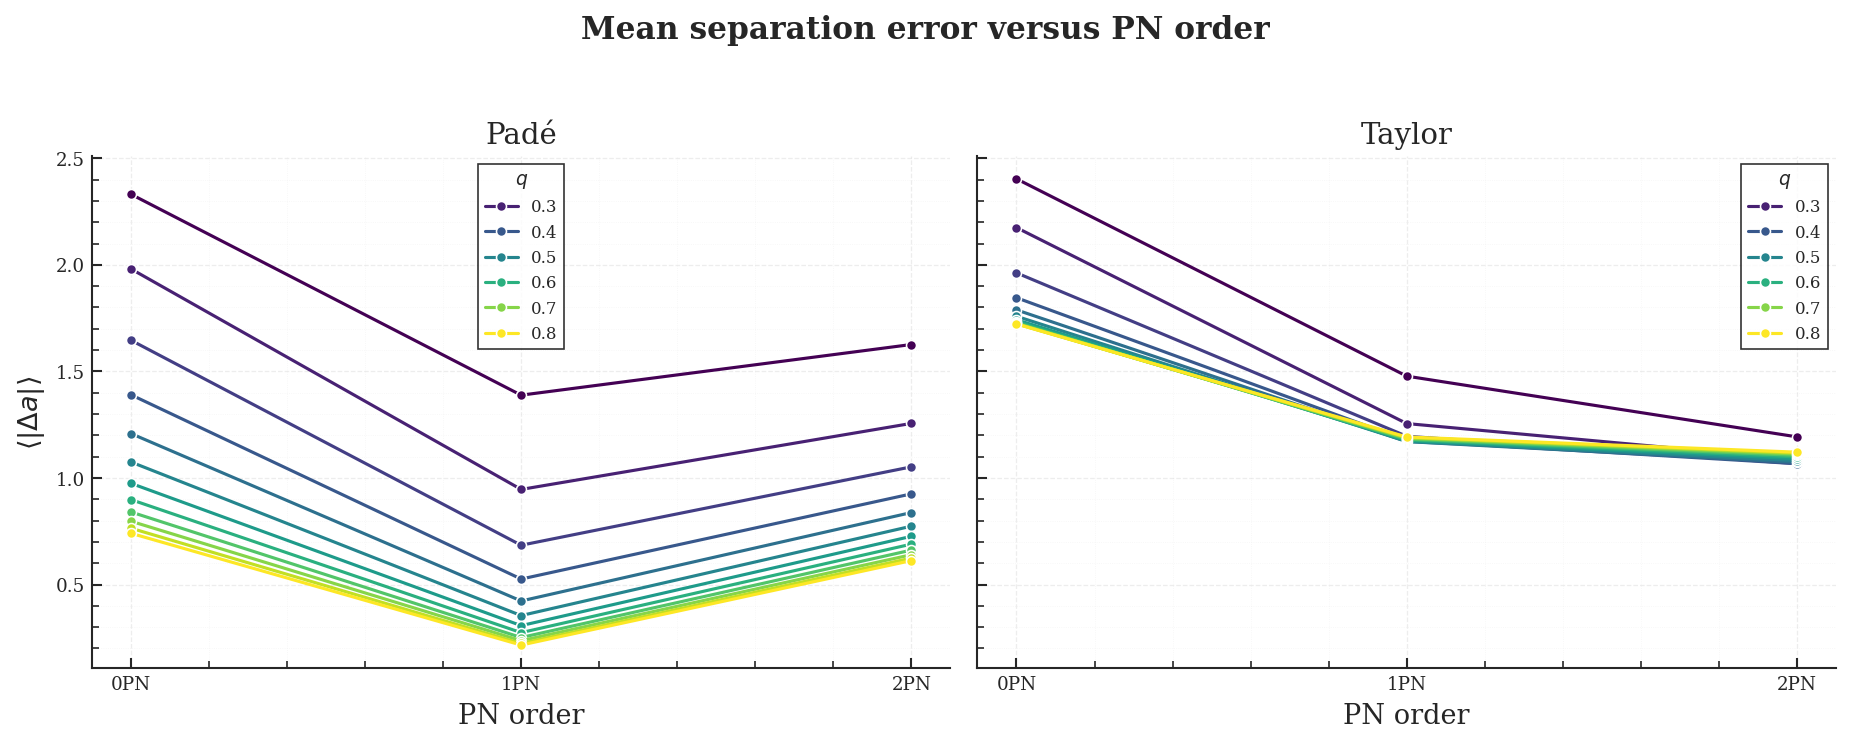

In [19]:
# ============================================================
# Mean separation error versus PN order, split by method
# ============================================================
sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

methods = ["Padé", "Taylor"]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 4.8),
    dpi=150,
    sharey=True
)

for ax, method_name in zip(axes, methods):

    df_method = summary_error_df[
        summary_error_df["method"] == method_name
    ].copy()

    sns.lineplot(
        data=df_method,
        x="PN_order",
        y="mean_abs_delta_a",
        hue="q",
        marker="o",
        linewidth=1.5,
        ax=ax,
        palette="viridis"
    )

    ax.set_title(rf"{method_name}")
    ax.set_xlabel("PN order")
    ax.set_ylabel(r"$\langle |\Delta a| \rangle$")

    ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.35)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.4, alpha=0.18)
    ax.minorticks_on()

    ax.legend(
        title=r"$q$",
        frameon=True,
        edgecolor="black",
        fancybox=False,
        fontsize=8,
        title_fontsize=9
    )

fig.suptitle(
    r"Mean separation error versus PN order",
    fontsize=15,
    fontweight="bold",
    y=1.03
)

sns.despine()
plt.tight_layout()

fig.savefig(
    fig_dir / "15_4_mean_abs_delta_vs_pn_order_split_method.pdf",
    bbox_inches="tight"
)

fig.savefig(
    fig_dir / "15_4_mean_abs_delta_vs_pn_order_split_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

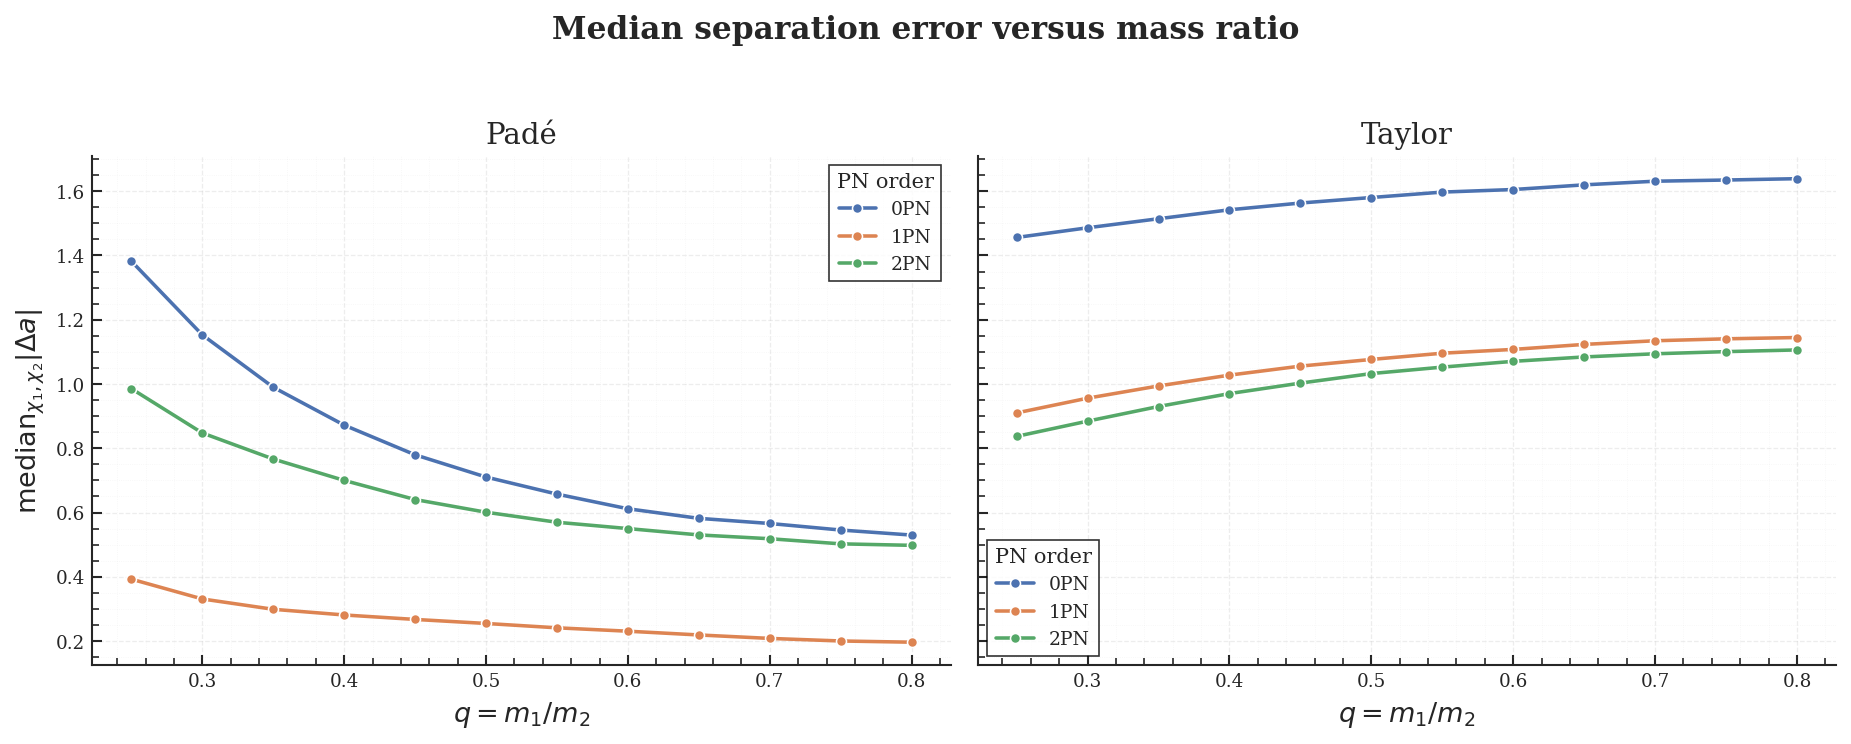

In [20]:
# ============================================================
# Median separation error versus mass ratio, split by method
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 4.8),
    dpi=150,
    sharey=True
)

for ax, method_name in zip(axes, methods):

    df_method = summary_error_df[
        summary_error_df["method"] == method_name
    ].copy()

    sns.lineplot(
        data=df_method,
        x="q",
        y="median_abs_delta_a",
        hue="PN_order",
        marker="o",
        linewidth=1.7,
        ax=ax
    )

    ax.set_title(rf"{method_name}")
    ax.set_xlabel(r"$q=m_1/m_2$")
    ax.set_ylabel(r"${\rm median}_{\chi_1,\chi_2}|\Delta a|$")

    ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.35)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.4, alpha=0.18)
    ax.minorticks_on()

    ax.legend(
        title="PN order",
        frameon=True,
        edgecolor="black",
        fancybox=False,
        fontsize=9,
        title_fontsize=10
    )

fig.suptitle(
    r"Median separation error versus mass ratio",
    fontsize=15,
    fontweight="bold",
    y=1.03
)

sns.despine()
plt.tight_layout()

fig.savefig(
    fig_dir / "15_4_median_abs_delta_vs_q_split_method.pdf",
    bbox_inches="tight"
)

fig.savefig(
    fig_dir / "15_4_median_abs_delta_vs_q_split_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

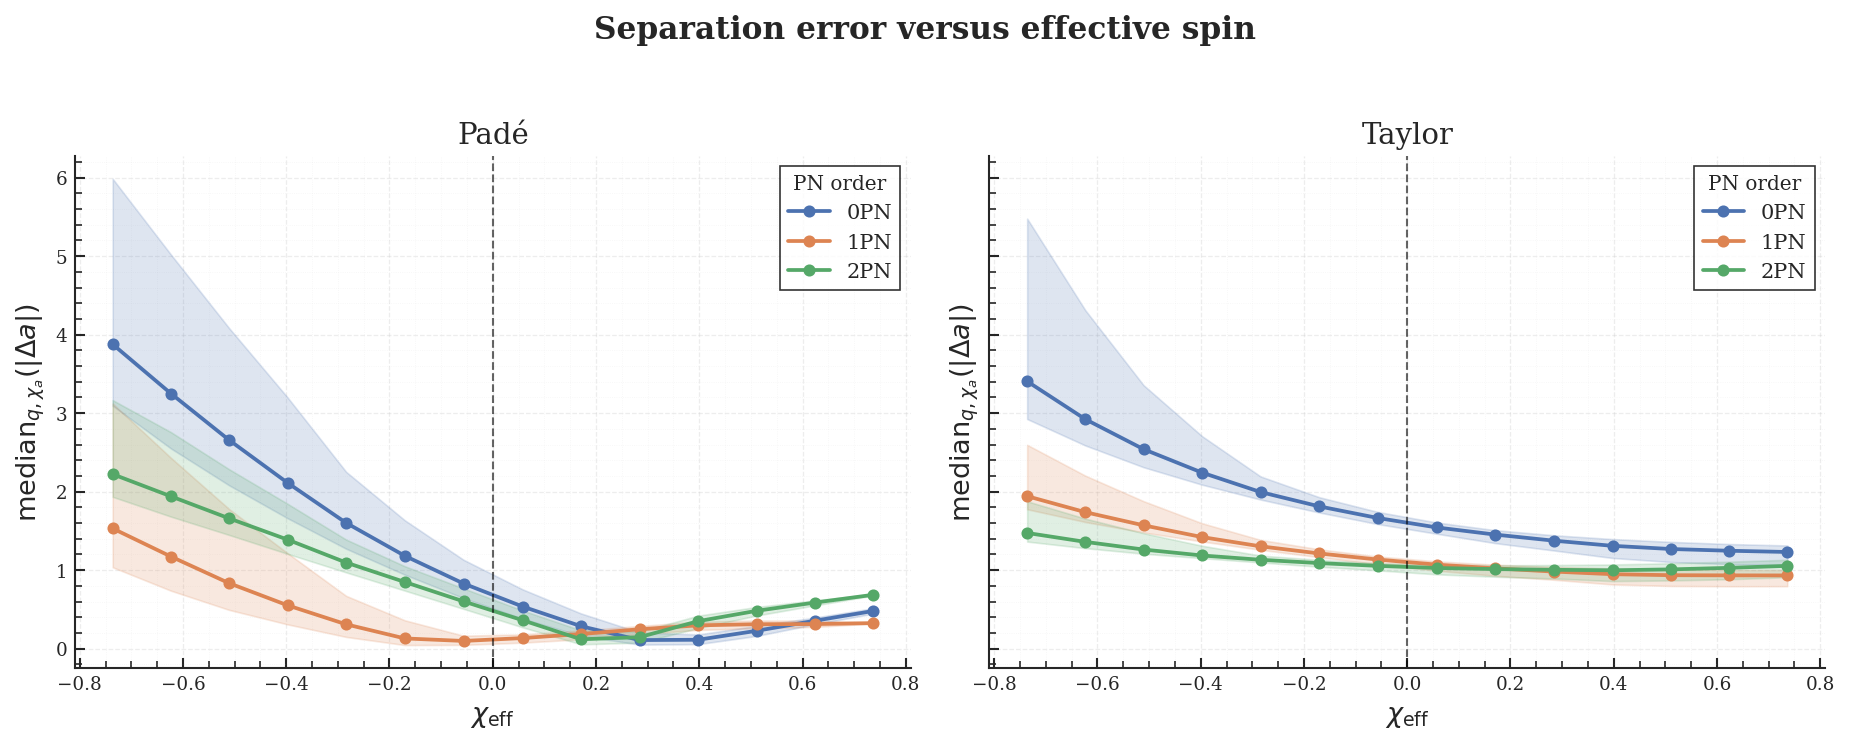

In [21]:
# ============================================================
# Error versus chi_eff, collapsed over mass ratio q
# ============================================================

sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})


if "chi_eff" not in combined_heatmap_df.columns:

    q = combined_heatmap_df["q"].to_numpy(dtype=float)
    chi1 = combined_heatmap_df["chi1_z"].to_numpy(dtype=float)
    chi2 = combined_heatmap_df["chi2_z"].to_numpy(dtype=float)

    m1 = q / (1.0 + q)
    m2 = 1.0 / (1.0 + q)

    combined_heatmap_df["chi_eff"] = m1 * chi1 + m2 * chi2


n_bins = 14

chi_eff_edges = np.linspace(
    combined_heatmap_df["chi_eff"].min(),
    combined_heatmap_df["chi_eff"].max(),
    n_bins + 1
)

combined_heatmap_df["chi_eff_bin"] = pd.cut(
    combined_heatmap_df["chi_eff"],
    bins=chi_eff_edges,
    include_lowest=True
)


chi_eff_summary = (
    combined_heatmap_df
    .groupby(["method", "PN_order", "chi_eff_bin"], observed=True)
    .agg(
        chi_eff_mean=("chi_eff", "mean"),
        median_abs_delta_a=("abs_delta_a", "median"),
        p25_abs_delta_a=("abs_delta_a", lambda x: np.nanpercentile(x, 25)),
        p75_abs_delta_a=("abs_delta_a", lambda x: np.nanpercentile(x, 75)),
        mean_abs_delta_a=("abs_delta_a", "mean"),
        n=("abs_delta_a", lambda x: np.sum(np.isfinite(x))),
    )
    .reset_index()
)


methods = ["Padé", "Taylor"]
pn_orders = ["0PN", "1PN", "2PN"]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 4.8),
    dpi=150,
    sharey=True
)

palette = dict(zip(
    pn_orders,
    sns.color_palette("deep", n_colors=len(pn_orders))
))

for ax, method_name in zip(axes, methods):

    df_method = chi_eff_summary[
        chi_eff_summary["method"] == method_name
    ].copy()

    for pn_order in pn_orders:

        df_pn = df_method[
            df_method["PN_order"] == pn_order
        ].copy()

        df_pn = df_pn[
            np.isfinite(df_pn["chi_eff_mean"])
            &
            np.isfinite(df_pn["median_abs_delta_a"])
        ].sort_values("chi_eff_mean")

        if len(df_pn) == 0:
            continue

        x = df_pn["chi_eff_mean"].to_numpy(dtype=float)
        y = df_pn["median_abs_delta_a"].to_numpy(dtype=float)
        y25 = df_pn["p25_abs_delta_a"].to_numpy(dtype=float)
        y75 = df_pn["p75_abs_delta_a"].to_numpy(dtype=float)

        color = palette[pn_order]

        ax.plot(
            x,
            y,
            marker="o",
            linewidth=1.8,
            label=pn_order,
            color=color
        )

        ax.fill_between(
            x,
            y25,
            y75,
            alpha=0.18,
            color=color
        )

    ax.set_title(method_name)
    ax.set_xlabel(r"$\chi_{\rm eff}$")
    ax.set_ylabel(r"${\rm median}_{q,\chi_a}(|\Delta a|)$")

    ax.axvline(
        0.0,
        color="black",
        linestyle="--",
        linewidth=1.0,
        alpha=0.6
    )

    ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.35)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.4, alpha=0.18)
    ax.minorticks_on()

    ax.legend(
        title="PN order",
        frameon=True,
        edgecolor="black",
        fancybox=False
    )

fig.suptitle(
    r"Separation error versus effective spin",
    fontsize=15,
    fontweight="bold",
    y=1.03
)

sns.despine()
plt.tight_layout()

fig.savefig(
    fig_dir / "15_6_error_vs_chi_eff_collapsed_over_q.pdf",
    bbox_inches="tight"
)

fig.savefig(
    fig_dir / "15_6_error_vs_chi_eff_collapsed_over_q.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

PADE' CHECK

Testing configuration:
q       = 0.5
chi1_z  = 0.3
chi2_z  = -0.7


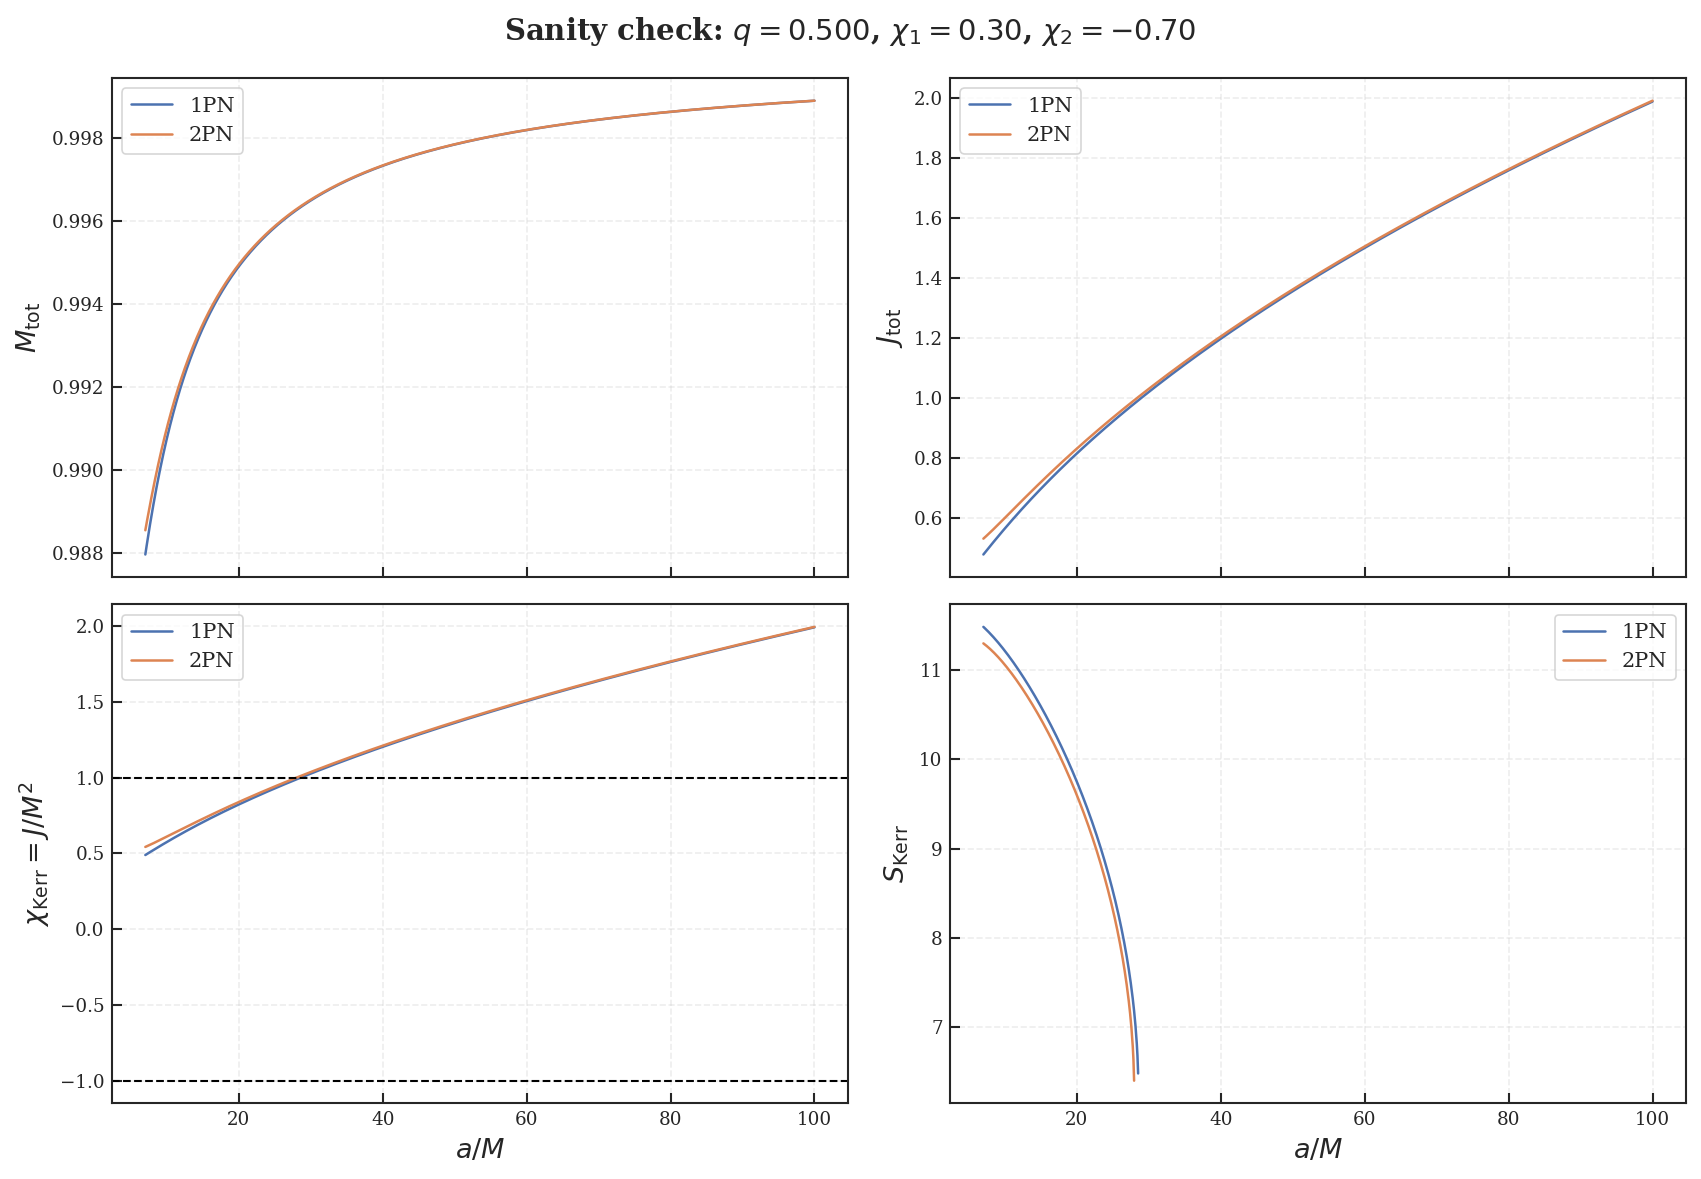

In [22]:
# ============================================================
# Single-configuration sanity check: 1PN vs 2PN curves
# ============================================================

q_test = 0.5
chi1_test = 0.3
chi2_test = -0.7

print("Testing configuration:")
print(f"q       = {q_test}")
print(f"chi1_z  = {chi1_test}")
print(f"chi2_z  = {chi2_test}")

params_test = aligned_binary_parameters(
    q_test,
    chi1_test,
    chi2_test
)

a_test = np.linspace(100.0, 7.0, 1000)

curve_1PN_test = aligned_entropy_curve_1PN(
    a_test,
    params_test
)

curve_2PN_test = aligned_entropy_curve_2PN(
    a_test,
    params_test
)


fig, axes = plt.subplots(
    2,
    2,
    figsize=(11.5, 8.0),
    dpi=150,
    sharex=True
)

axes = axes.ravel()

axes[0].plot(
    curve_1PN_test["a"],
    curve_1PN_test["M_tot_1PN"],
    label="1PN"
)
axes[0].plot(
    curve_2PN_test["a"],
    curve_2PN_test["M_tot_2PN"],
    label="2PN"
)
axes[0].set_ylabel(r"$M_{\rm tot}$")
axes[0].legend()

axes[1].plot(
    curve_1PN_test["a"],
    curve_1PN_test["J_tot_abs_1PN"],
    label="1PN"
)
axes[1].plot(
    curve_2PN_test["a"],
    curve_2PN_test["J_tot_abs_2PN"],
    label="2PN"
)
axes[1].set_ylabel(r"$J_{\rm tot}$")
axes[1].legend()

axes[2].plot(
    curve_1PN_test["a"],
    curve_1PN_test["chi_Kerr_1PN"],
    label="1PN"
)
axes[2].plot(
    curve_2PN_test["a"],
    curve_2PN_test["chi_Kerr_2PN"],
    label="2PN"
)
axes[2].axhline(1.0, color="black", linestyle="--", linewidth=1.0)
axes[2].axhline(-1.0, color="black", linestyle="--", linewidth=1.0)
axes[2].set_ylabel(r"$\chi_{\rm Kerr}=J/M^2$")
axes[2].set_xlabel(r"$a/M$")
axes[2].legend()

axes[3].plot(
    curve_1PN_test["a"],
    curve_1PN_test["S_Kerr_1PN"],
    label="1PN"
)
axes[3].plot(
    curve_2PN_test["a"],
    curve_2PN_test["S_Kerr_2PN"],
    label="2PN"
)
axes[3].set_ylabel(r"$S_{\rm Kerr}$")
axes[3].set_xlabel(r"$a/M$")
axes[3].legend()

for ax in axes:
    ax.invert_xaxis()
    ax.grid(True, linestyle="--", alpha=0.35)

fig.suptitle(
    rf"Sanity check: $q={q_test:.3f}$, $\chi_1={chi1_test:.2f}$, $\chi_2={chi2_test:.2f}$",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

a_star 1PN = 4.157052350783594
a_star 2PN = 4.910303434478159
a_star 2PN - 1PN = 0.7532510836945647


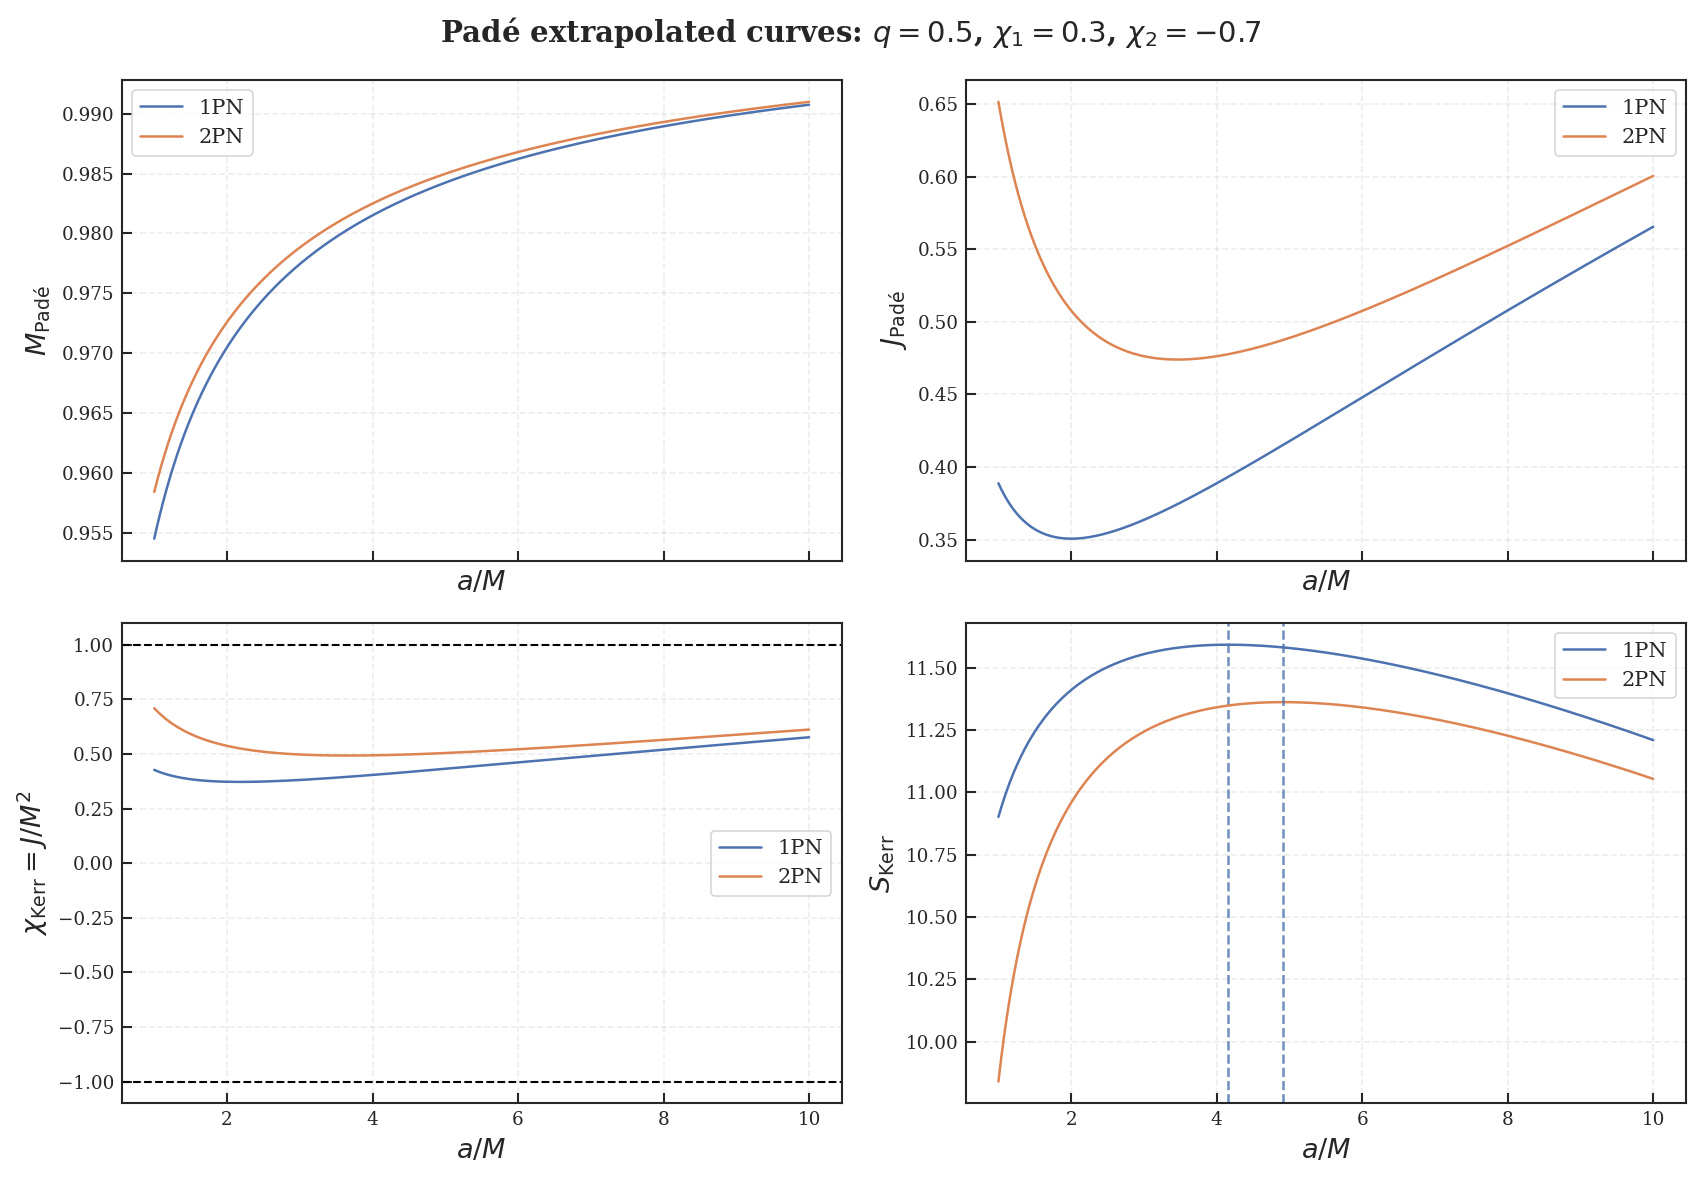

In [23]:
# ============================================================
# Inspect Padé-extrapolated 1PN and 2PN curves directly
# ============================================================

def pade_2_1(v, p0, p1, p2, q1):
    return (p0 + p1*v + p2*v**2) / (1.0 + q1*v)


def fit_and_extrapolate_pade_debug(curve, M_col, J_col):
    fit_mask = (
        np.isfinite(curve["a"])
        &
        np.isfinite(curve[M_col])
        &
        np.isfinite(curve[J_col])
        &
        (curve["a"] >= 10.0)
        &
        (curve["a"] <= 40.0)
    )

    fit_data = curve.loc[fit_mask].copy()

    fit_data["v"] = 1.0 / np.sqrt(fit_data["a"])
    fit_data = fit_data.sort_values("v")

    v_fit = fit_data["v"].to_numpy(dtype=float)
    M_fit = fit_data[M_col].to_numpy(dtype=float)
    J_fit = fit_data[J_col].to_numpy(dtype=float)

    p0 = [1.0, 1.0, 1.0, 0.0]

    popt_M, _ = curve_fit(
        pade_2_1,
        v_fit,
        M_fit,
        p0=p0,
        maxfev=20000
    )

    popt_J, _ = curve_fit(
        pade_2_1,
        v_fit,
        J_fit,
        p0=p0,
        maxfev=20000
    )

    a_ext = np.linspace(10.0, 1.0, 3000)
    v_ext = 1.0 / np.sqrt(a_ext)

    M_ext = pade_2_1(v_ext, *popt_M)
    J_ext = pade_2_1(v_ext, *popt_J)

    S_ext, chi_ext = kerr_entropy(
        M_ext,
        J_ext,
        return_chi=True
    )

    physical = (
        np.isfinite(a_ext)
        &
        np.isfinite(M_ext)
        &
        np.isfinite(J_ext)
        &
        np.isfinite(S_ext)
        &
        np.isfinite(chi_ext)
        &
        (M_ext > 0.0)
        &
        (np.abs(chi_ext) <= 1.0)
    )

    if np.any(physical):
        idx = np.nanargmax(S_ext[physical])
        a_star = a_ext[physical][idx]
    else:
        a_star = np.nan

    return {
        "a": a_ext,
        "M": M_ext,
        "J": J_ext,
        "chi": chi_ext,
        "S": S_ext,
        "physical": physical,
        "a_star": a_star,
        "popt_M": popt_M,
        "popt_J": popt_J,
    }


params_test = aligned_binary_parameters(
    q_test,
    chi1_test,
    chi2_test
)

a_test = np.linspace(100.0, 7.0, 1000)

curve_1PN_test = aligned_entropy_curve_1PN(
    a_test,
    params_test
)

curve_2PN_test = aligned_entropy_curve_2PN(
    a_test,
    params_test
)

pade_1PN_debug = fit_and_extrapolate_pade_debug(
    curve_1PN_test,
    "M_tot_1PN",
    "J_tot_abs_1PN"
)

pade_2PN_debug = fit_and_extrapolate_pade_debug(
    curve_2PN_test,
    "M_tot_2PN",
    "J_tot_abs_2PN"
)

print("a_star 1PN =", pade_1PN_debug["a_star"])
print("a_star 2PN =", pade_2PN_debug["a_star"])
print("a_star 2PN - 1PN =", pade_2PN_debug["a_star"] - pade_1PN_debug["a_star"])

fig, axes = plt.subplots(
    2,
    2,
    figsize=(11.5, 8.0),
    dpi=150,
    sharex=True
)

axes = axes.ravel()

for label, out in [
    ("1PN", pade_1PN_debug),
    ("2PN", pade_2PN_debug),
]:

    physical = out["physical"]

    axes[0].plot(out["a"], out["M"], label=label)
    axes[1].plot(out["a"], out["J"], label=label)
    axes[2].plot(out["a"], out["chi"], label=label)
    axes[3].plot(out["a"][physical], out["S"][physical], label=label)

    axes[3].axvline(
        out["a_star"],
        linestyle="--",
        linewidth=1.2,
        alpha=0.8
    )

axes[0].set_ylabel(r"$M_{\rm Padé}$")
axes[1].set_ylabel(r"$J_{\rm Padé}$")
axes[2].set_ylabel(r"$\chi_{\rm Kerr}=J/M^2$")
axes[3].set_ylabel(r"$S_{\rm Kerr}$")

axes[2].axhline(1.0, color="black", linestyle="--", linewidth=1.0)
axes[2].axhline(-1.0, color="black", linestyle="--", linewidth=1.0)

for ax in axes:
    ax.set_xlabel(r"$a/M$")
    ax.invert_xaxis()
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend()

fig.suptitle(
    rf"Padé extrapolated curves: $q={q_test}$, $\chi_1={chi1_test}$, $\chi_2={chi2_test}$",
    fontsize=14,
    fontweight="bold"
)


plt.tight_layout()
plt.show()

2PN check

In [24]:
# ============================================================
# Diagnostic: angular-momentum term hierarchy at fixed a
# ============================================================

def inspect_2PN_angular_momentum_terms(q_test, chi1_test, chi2_test, a_values=[10.0, 5.0, 3.0]):
    
    params_test = aligned_binary_parameters(
        q_test,
        chi1_test,
        chi2_test
    )

    curve = aligned_entropy_curve_2PN(
        np.array(a_values, dtype=float),
        params_test
    )

    cols = [
        "a",
        "L_orb_N",
        "L_orb_1PN_corr",
        "L_SO_15PN_corr",
        "L_orb_2PN_NS_corr",
        "L_SS_2PN_corr",
        "L_ell_2PN",
        "J_tot_z_2PN",
        "chi_Kerr_2PN",
    ]

    out = curve[cols].copy()

    out["L_1PN_over_LN"] = out["L_orb_1PN_corr"] / out["L_orb_N"]
    out["L_SO_over_LN"] = out["L_SO_15PN_corr"] / out["L_orb_N"]
    out["L_2PN_NS_over_LN"] = out["L_orb_2PN_NS_corr"] / out["L_orb_N"]
    out["L_SS_over_LN"] = out["L_SS_2PN_corr"] / out["L_orb_N"]

    return out


term_check = inspect_2PN_angular_momentum_terms(
    q_test=0.5,
    chi1_test=-0.8,
    chi2_test=0.5,
    a_values=[10.0, 5.0, 3.0, 2.0]
)

display(term_check)

,a,L_orb_N,L_orb_1PN_corr,L_SO_15PN_corr,L_orb_2PN_NS_corr,L_SS_2PN_corr,L_ell_2PN,J_tot_z_2PN,chi_Kerr_2PN,L_1PN_over_LN,L_SO_over_LN,L_2PN_NS_over_LN,L_SS_over_LN
0,10.0,0.702728,0.140546,-0.006173,0.010541,-0.000031,0.847611,0.980944,0.999572,0.200000,-0.008784,0.015000,-0.000044
1,5.0,0.496904,0.198762,-0.012346,0.029814,-0.000088,0.713046,0.846379,0.873372,0.400000,-0.024845,0.060000,-0.000178
2,3.0,0.384900,0.256600,-0.020576,0.064150,-0.000190,0.684884,0.818217,0.851514,0.666667,-0.053458,0.166667,-0.000494
3,2.0,0.314270,0.314270,-0.030864,0.117851,-0.000349,0.715177,0.848510,0.883049,1.000000,-0.098209,0.375000,-0.001111
